In [2]:
from sim_loader.abacus_io import AbacusSummitSim
from HODDIES.hod import HOD
# from sim_loader import setup_logging
import numpy as np
import matplotlib.pyplot as plt
# setup_logging()
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/dvs_ro/cfs/cdirs/desi/cosmosim/Abacus',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3001',  # Specific to Abacus simulation
    'load_particles': False,  # Whether to load particle/subhalos data
}
test=AbacusSummitSim(**default_abacus_param)

HOD_obj = HOD(base_catalog=test, tracers='LRG', setup_logger=False)


ImportError: /global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/torch/lib/../../nvidia/cublas/lib/libcublas.so.12: undefined symbol: cublasLtGetEnvironmentMode, version libcublasLt.so.12

In [1]:
from fit_functions.FCNN_utils import make_training_dataset, train_model
dataset_path = '/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test_no_fixseed/AbacusSummit_base_c000_ph000/z0.500/training_set/LRG_SHOD_6p/Hammersley/'
testset_path='/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test_no_fixseed/AbacusSummit_base_c000_ph000/z0.500/test_set/LRG_SHOD_6p/lhs/'
path_to_model='/global/homes/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/saved_model/test_model_LRG_SHOD_6p_z0.5_small_wp+xi_ells.pth'
path_to_model=None
# testset_path=None
num_testset=800
train_Dataset, train_loader, val_loader = make_training_dataset(dataset_path, stats=['wp', 'xi_ells'], log_transform=['wp'], seed=421, batch_size=256, path_to_test_files=testset_path, num_testset=num_testset, device='cpu')
# model = train_model(train_loader=train_loader, min_epochs=100, val_l  oader=val_loader, use_std=False, Activation_fn="SiLU", path_to_model=path_to_model)
file_best_fit_train = '/global/homes/a/arocher/Code/postdoc/HOD/Cosmological_emulator_ELGs/best_train_model.npy'

model = train_model(train_loader=train_loader, min_epochs=100, val_loader=val_loader, file_best_fit_train=file_best_fit_train, use_std=False,
                    Activation_fn="SiLU", path_to_model=path_to_model, device='cpu')

Loading test files from /global/cfs/cdirs/desi/users/arocher/HODDIES_results/test_no_fixseed/AbacusSummit_base_c000_ph000/z0.500/test_set/LRG_SHOD_6p/lhs/
Loading training files from /global/cfs/cdirs/desi/users/arocher/HODDIES_results/test_no_fixseed/AbacusSummit_base_c000_ph000/z0.500/training_set/LRG_SHOD_6p/Hammersley/
Applying arcsinh transform to wp
Using device: cpu


/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py:592: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = GradScaler(enabled=self.use_amp)


Model device cpu


/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py:768: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):
/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py:874: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


Epoch 1/5000 - Train: 1.46655 | Val: 1.13366
Epoch 11/5000 - Train: 0.81095 | Val: 0.75158
Epoch 21/5000 - Train: -0.35750 | Val: -0.28957
Epoch 31/5000 - Train: -0.01537 | Val: -0.28620
Epoch 41/5000 - Train: -1.03311 | Val: -1.02869
Epoch 51/5000 - Train: -1.02293 | Val: -1.36941
Epoch 61/5000 - Train: -0.53820 | Val: 1.33854
Epoch 71/5000 - Train: -1.36389 | Val: -1.48348
Epoch 81/5000 - Train: -2.01611 | Val: -2.04512
Epoch 91/5000 - Train: -2.16891 | Val: -2.03029
Epoch 101/5000 - Train: -2.43285 | Val: -2.34900
Epoch 111/5000 - Train: -2.42562 | Val: -2.47863
Epoch 121/5000 - Train: -1.11809 | Val: 0.55412
Epoch 131/5000 - Train: -2.27003 | Val: -2.36105
Epoch 141/5000 - Train: -2.58612 | Val: -2.61461
Epoch 151/5000 - Train: -2.74615 | Val: -2.74687
Epoch 161/5000 - Train: -2.75947 | Val: -2.83695
Epoch 171/5000 - Train: -2.96942 | Val: -2.90228
Epoch 181/5000 - Train: -2.92396 | Val: -2.94600
Epoch 191/5000 - Train: -3.01983 | Val: -2.99500
Epoch 201/5000 - Train: -3.06836 | Va

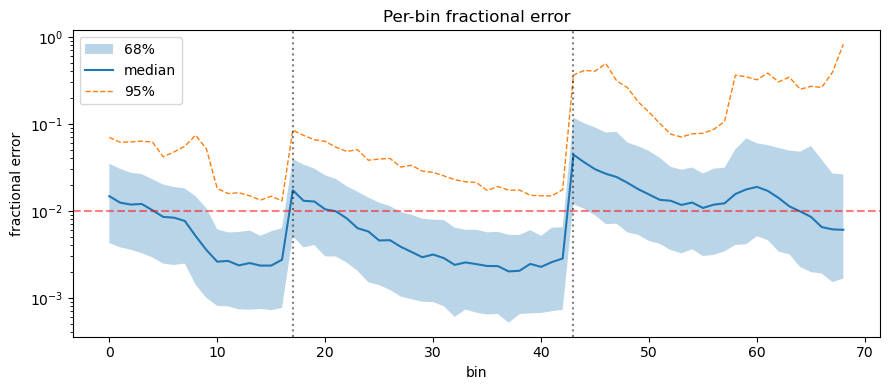

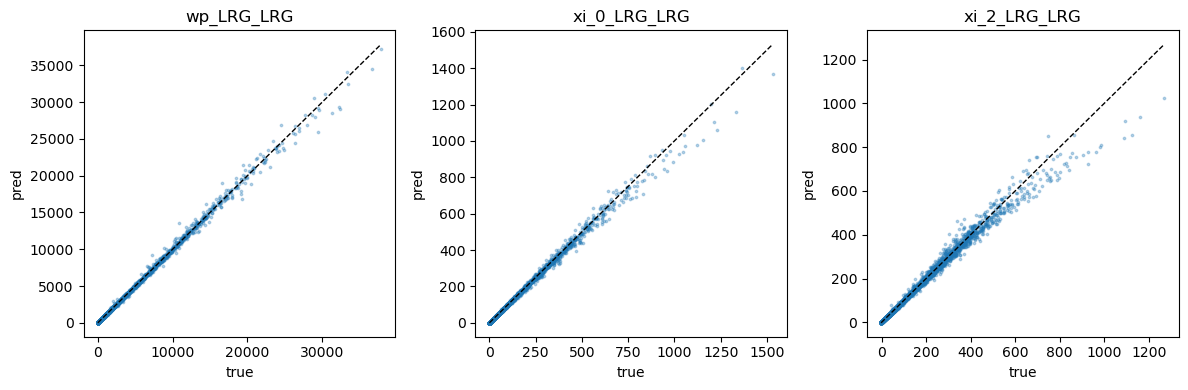

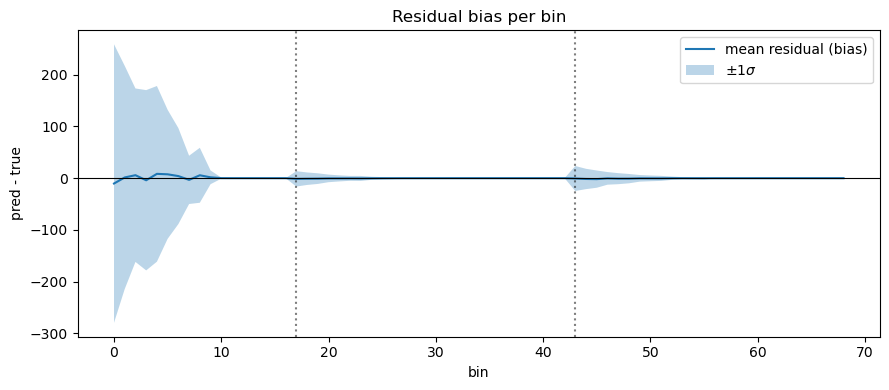

(<Figure size 900x400 with 1 Axes>,
 <Figure size 1200x400 with 3 Axes>,
 <Figure size 900x400 with 1 Axes>)

In [2]:
from HODDIES.fit_functions.plotting_emulator_func import plot_error_diagnostics, plot_verif
plot_error_diagnostics(train_Dataset, model)

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:331: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


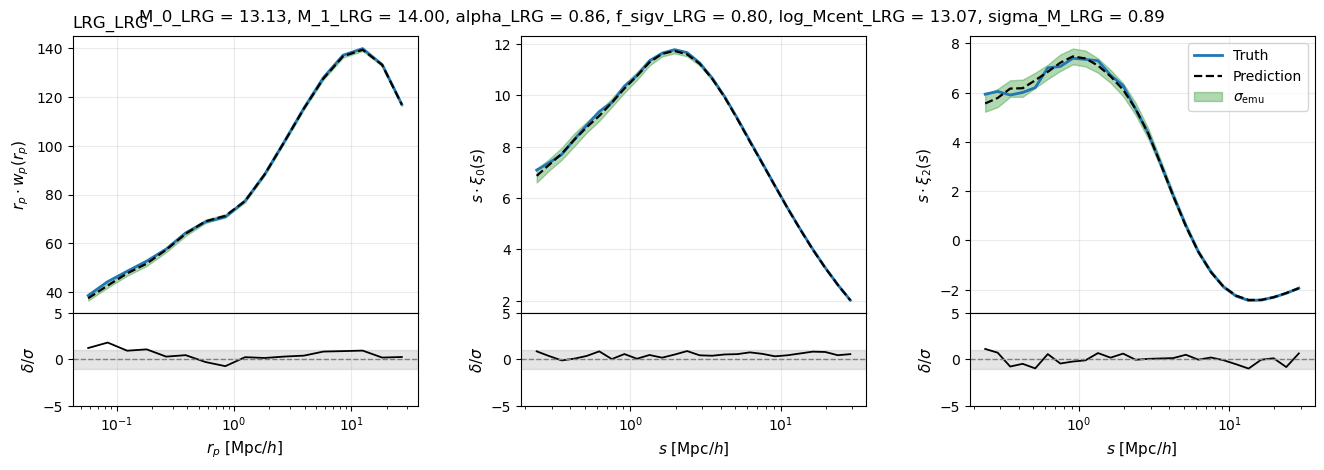

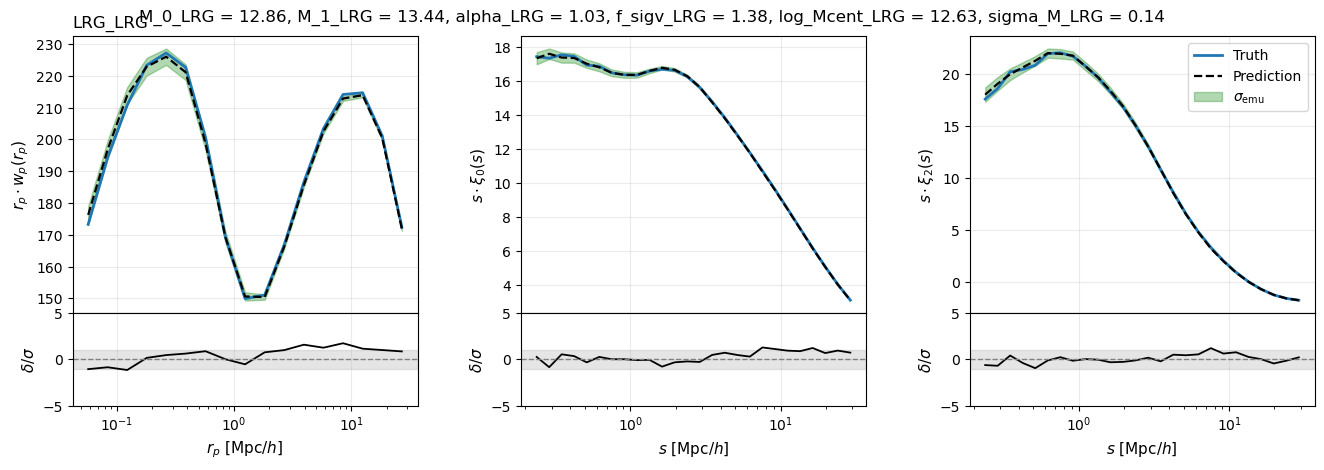

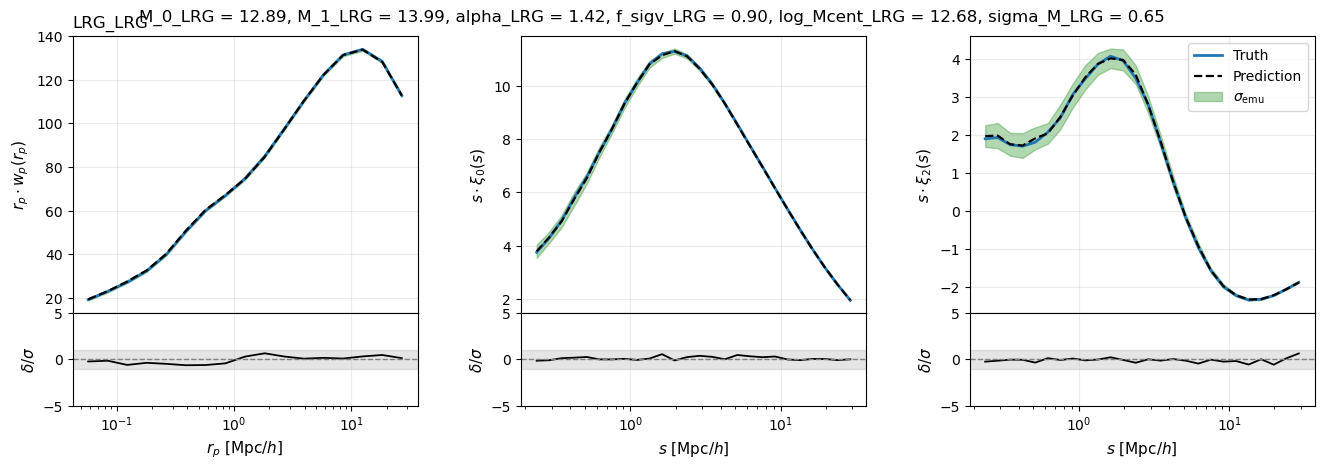

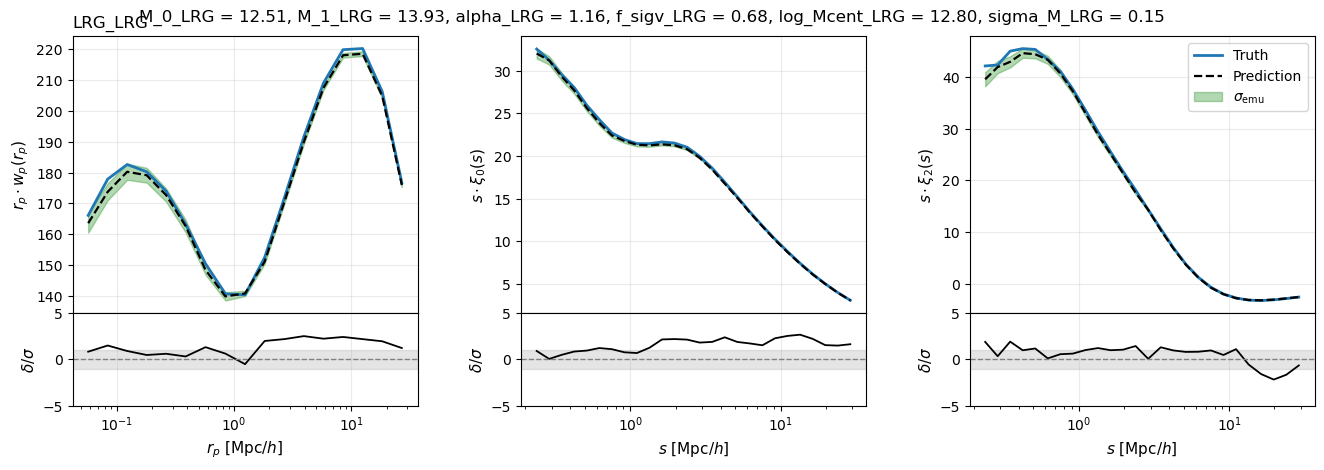

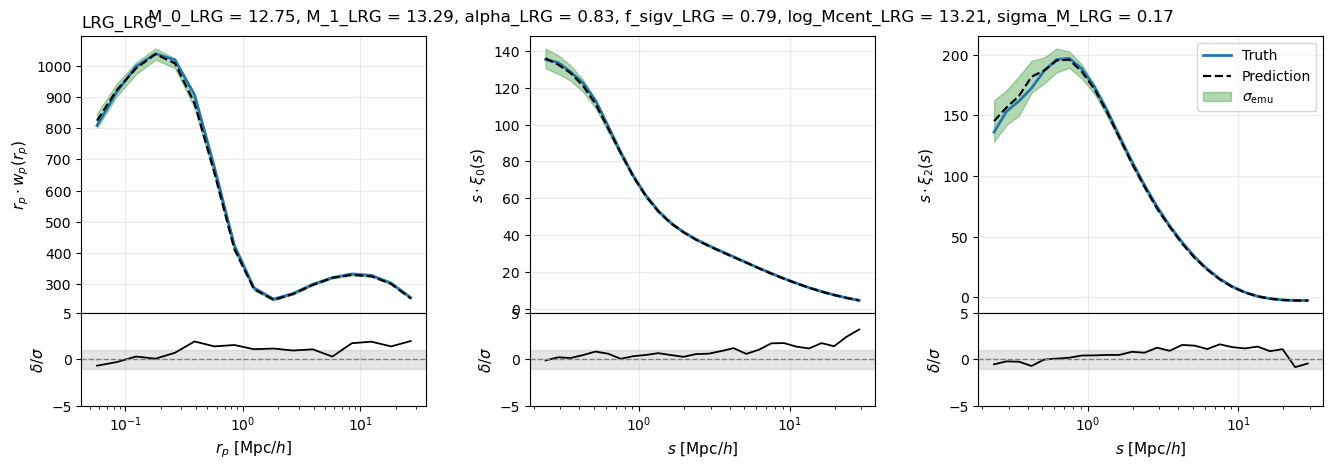

[<Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>]

In [3]:
plot_verif(train_Dataset, model, nb_plots=5) # auto scale (default)


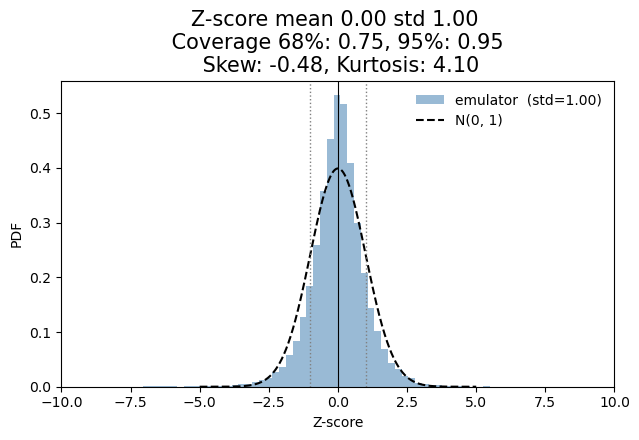

In [4]:
from HODDIES.fit_functions.FCNN_utils import Z_score
z, info = Z_score(model, train_Dataset, use_var_pred=True, use_red_prior=False, use_normalize=False, rescale_sigma=True, show=True)

In [17]:
import numpy as np
import torch

y_pred, var_pred = model.predict(torch.tensor(train_Dataset.x_test_norm, dtype=torch.float32))
y_pred, var_pred = train_Dataset.normalizer.denormalize_y(y_pred.squeeze().cpu().numpy(), var_pred.squeeze().cpu().numpy())
y_test = train_Dataset.y_test
# y_test = train_Dataset.y_test_norm
resid  = y_pred - y_test
rmse = np.sqrt(np.mean(resid**2))
mae  = np.mean(np.abs(resid))
# relative / fractional error (guard against divide-by-zero)
rel  = np.abs(resid) / np.abs(y_test)
mape = np.mean(rel) * 100
maxerr = np.max(np.abs(resid))
r2 = 1 - np.sum(resid**2) / np.sum((y_test - y_test.mean())**2)

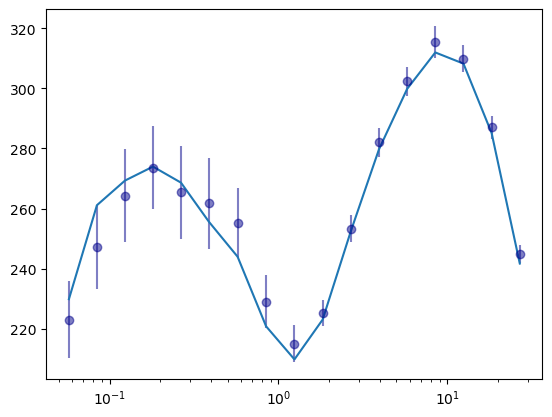

In [18]:
import matplotlib.pyplot as plt


# plt.errorbar(train_Dataset.data_dict['wp']['LRG_LRG'][0],train_Dataset.data_dict['wp']['LRG_LRG'][0]*y_pred[0][:17], train_Dataset.data_dict['wp']['LRG_LRG'][0]*np.sqrt(var.cpu().numpy()[0][:17]), fmt='o', label='Predicted', alpha=1, c='r')
plt.errorbar(train_Dataset.data_dict['wp']['LRG_LRG'][0],train_Dataset.data_dict['wp']['LRG_LRG'][0]*y_pred[0][:17], train_Dataset.data_dict['wp']['LRG_LRG'][0]*np.sqrt(var_pred[0][:17]), fmt='o', label='Predicted', alpha=0.5, c='darkblue' )
plt.semilogx(train_Dataset.data_dict['wp']['LRG_LRG'][0],train_Dataset.data_dict['wp']['LRG_LRG'][0]*train_Dataset.y_test[0][:17])


In [19]:
import numpy as np
import torch


def emulator_covariance_sunbird(model, train_Dataset,
                                use_red_prior=False, plot=True):
    """
    Emulator covariance from the test set, following Cuesta-Lazaro et al. 2023
    (SUNBIRD), equation 15:

        dX   = X_emu - X_test                       # (n_test, B), physical space
        Cemu = (1/(n_test-1)) * sum_k (dX_k - <dX>)(dX_k - <dX>)^T

    i.e. the mean-subtracted sample covariance of the emulator residuals.
    """
    B = train_Dataset.y_test.shape[1]

    # optional: restrict to test points inside the training prior
    if use_red_prior:
        q_lo, q_hi = np.quantile(train_Dataset.X_training, q=[0.025, 0.985], axis=0)
        mask = ((train_Dataset.X_test > q_lo) & (train_Dataset.X_test < q_hi)).all(axis=1)
    else:
        mask = np.ones(train_Dataset.x_test_norm.shape[0], dtype=bool)

    # emulator predictions (normalized -> physical)
    X = torch.tensor(train_Dataset.x_test_norm[mask], dtype=torch.float32).to(model.device)
    y_pred_norm = model.predict(X, no_grad=True)[0].cpu().numpy().reshape(-1, B)
    X_emu, _ = train_Dataset.normalizer.denormalize_y(y_pred_norm, None)
    X_emu  = X_emu.reshape(-1, B)
    X_test = train_Dataset.y_test[mask].reshape(-1, B)

    # equation 15
    dX = X_emu - X_test                              # (n_test, B)
    C_emu = np.cov(dX, rowvar=False, bias=False)     # mean-subtracted, 1/(n-1)
    std_emu = np.sqrt(C_emu.diagonal())
    # correlation matrix (their Fig. 2)
    d = np.sqrt(np.diag(C_emu))
    corr = C_emu / np.outer(d, d)

    n_test = dX.shape[0]
    hartlap = (n_test - B - 2) / (n_test - 1) if n_test > B + 2 else np.nan
    
    if plot:
        import matplotlib.pyplot as plt
        fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.6))
        im = a0.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", origin="lower")
        a0.set_title(r"$C_{\rm emu}$ correlation"); a0.set_xlabel("bin"); a0.set_ylabel("bin")
        fig.colorbar(im, ax=a0, fraction=0.046)
        a1.plot(np.arange(B), d, marker="o", ms=3)
        a1.set_yscale("log"); a1.set_title("per-bin emulator error"); a1.set_xlabel("bin")
        plt.tight_layout()

    return C_emu, corr, std_emu

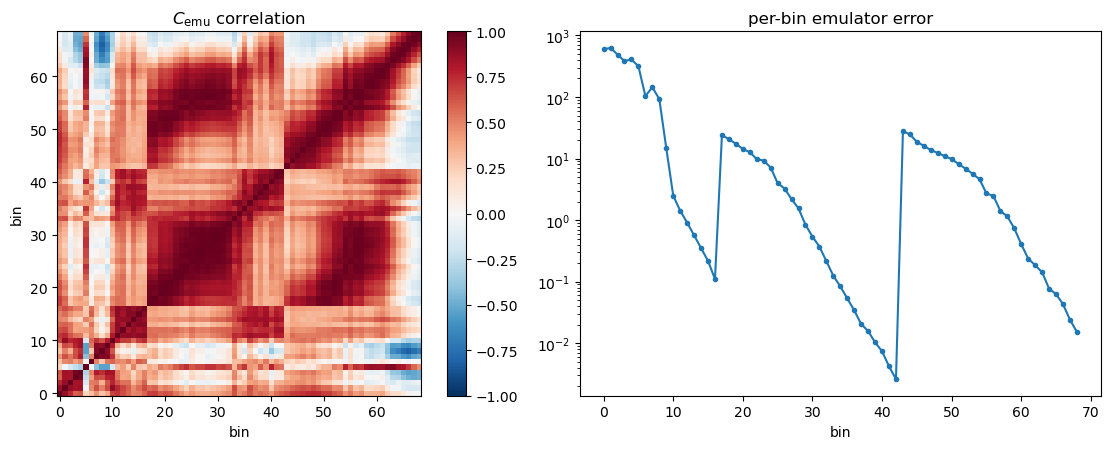

In [21]:
cov, corr, std_emu = emulator_covariance_sunbird(model, train_Dataset, use_red_prior=False, plot=True)

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:331: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


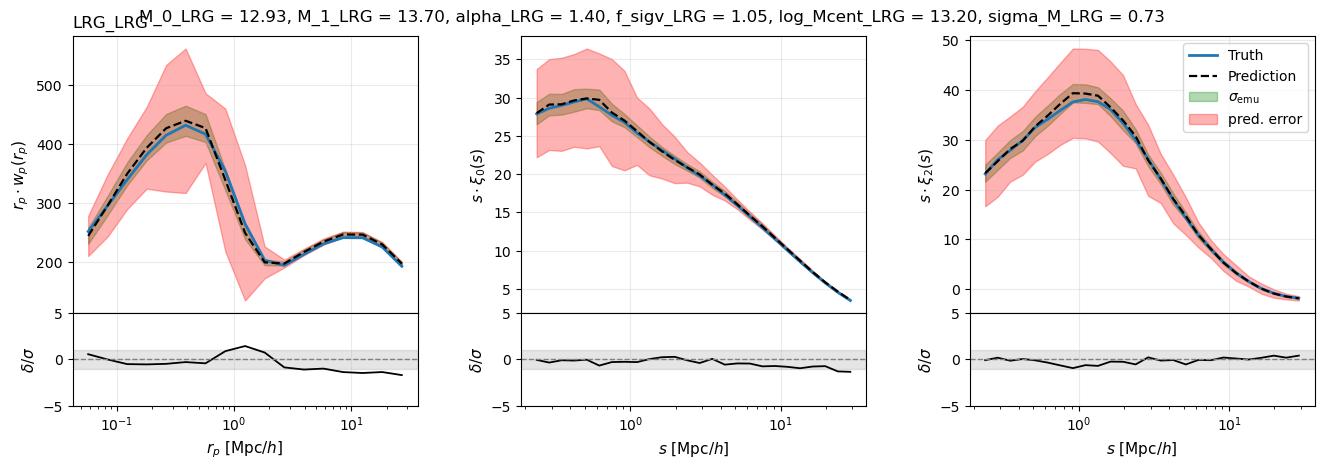

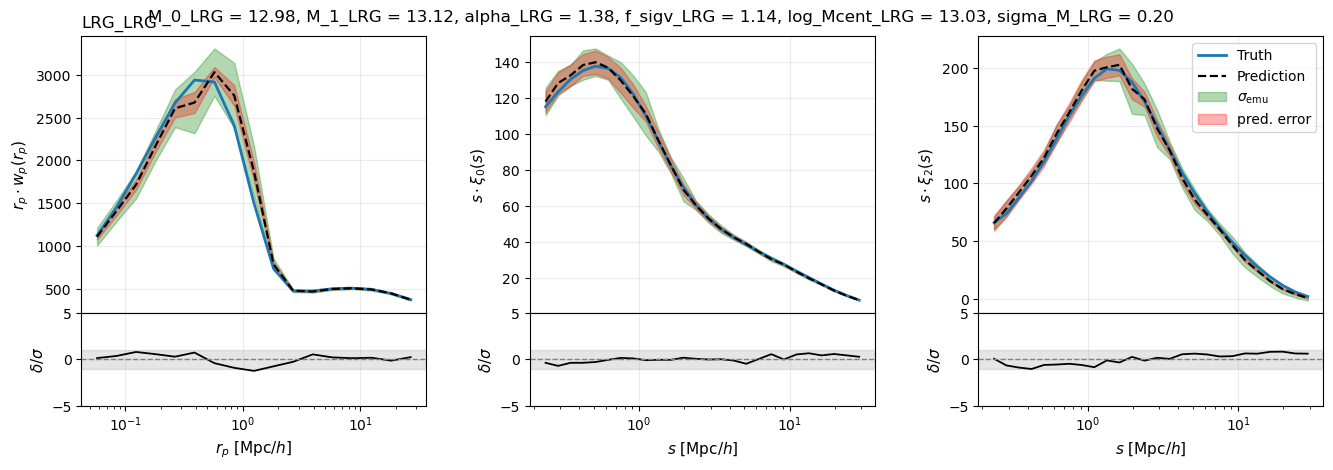

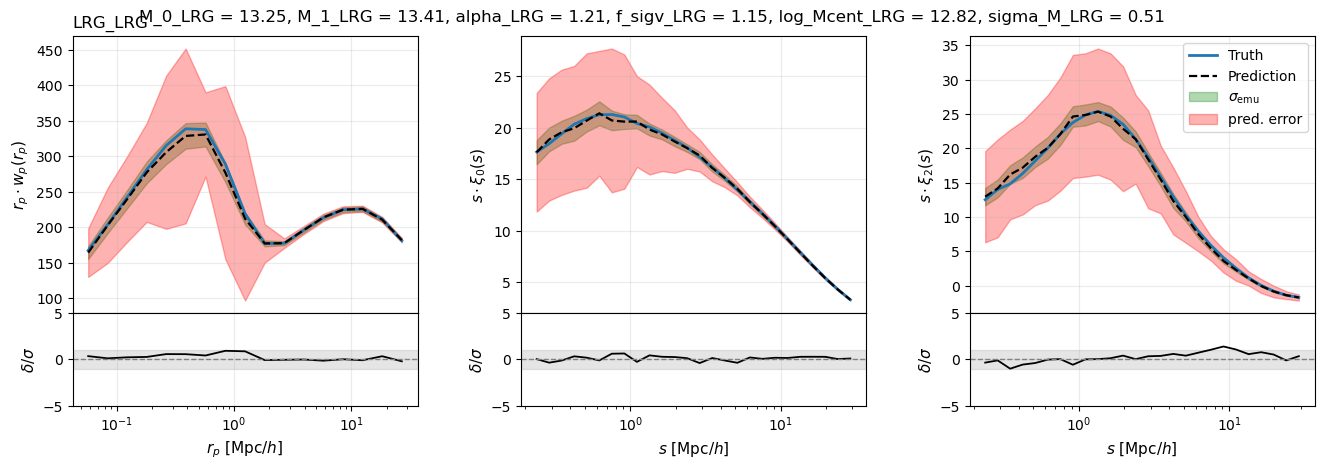

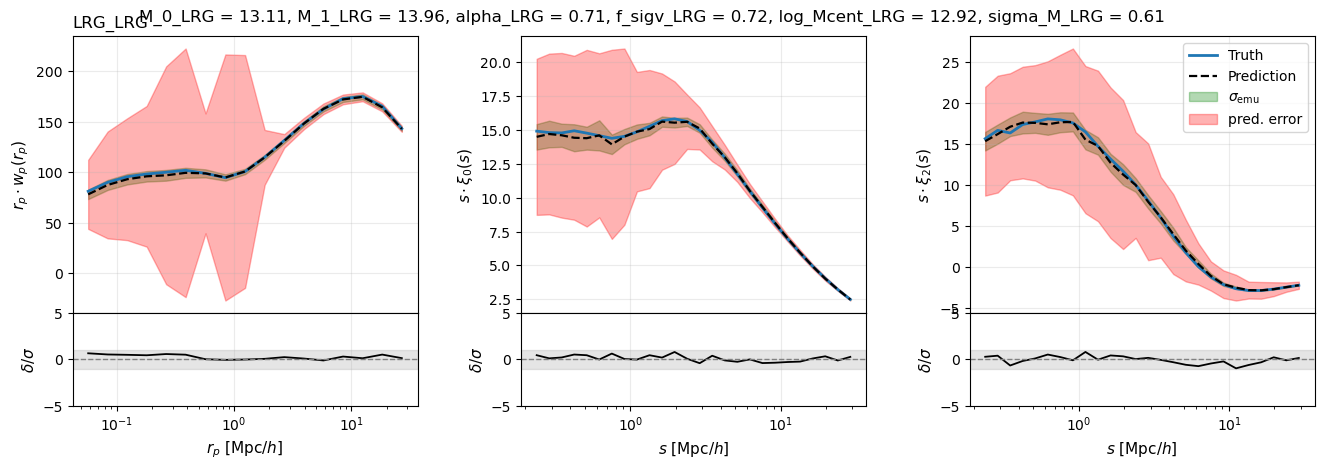

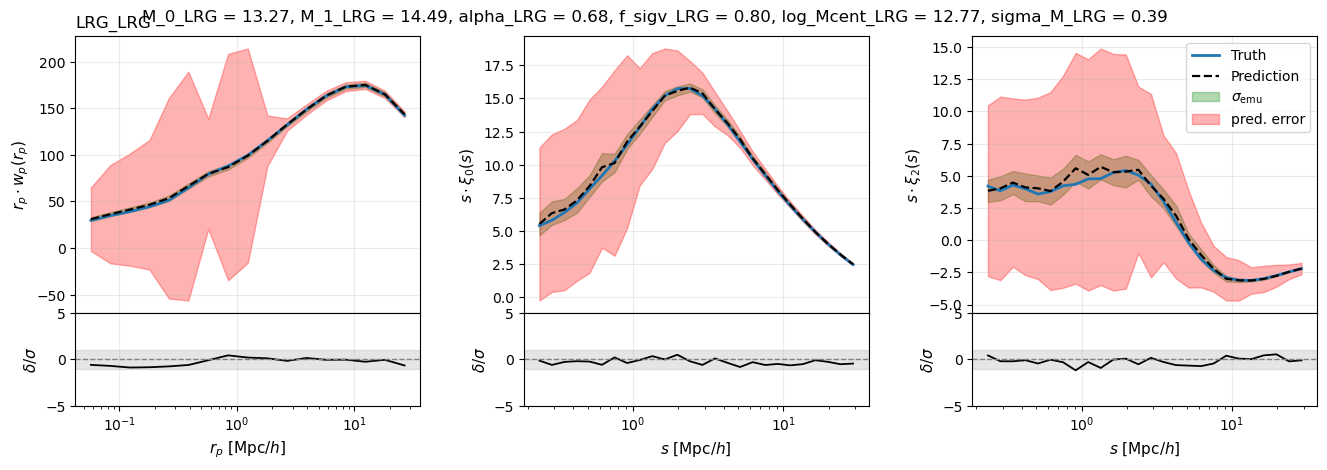

[<Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>,
 <Figure size 1380x440 with 6 Axes>]

In [22]:
from fit_functions.plotting_emulator_func import plot_verif 
plot_verif(train_Dataset, model, nb_plots=5, std_emu=std_emu) # auto scale (default)


In [26]:
def plot_training_stats(self, stats=None, data=None, data_err=None,
            max_cols=4, fontsize=11, block_hspace=0.55,
            wspace=0.30, colors=None, show=True):
    """Compare emulator predictions with the test set.

    One figure per test sample, one row of panels per tracer, wrapped at
    ``max_cols`` columns, with a ``(truth - prediction)/sigma`` sub-panel
    flush beneath each panel.

    Parameters
    ----------
    self : Training_DatasetManager
        Must expose ``slices``; ``coords`` (see note in the module
        docstring) is needed to split multipole blocks into panels.
    data : array-like
        The data to plot.
    model : object with ``predict``
    nb_plots : int
        Number of random test samples to show, ignored when ``indices``
        is given.
    stats : sequence of str or None
        Restrict to these statistics. ``None`` plots everything in
        ``slices``.
    indices : sequence of int or None
        Explicit test-set indices to plot.
    """    

    # ---- panels ------------------------------------------------------
    from HODDIES.fit_functions.plotting_emulator_func import _panels, _ylabel
    from matplotlib.gridspec import GridSpec

    panels = _panels(self, stats)
    if not panels:
        raise ValueError(
            f'no panels for stats={stats}; available slices: '
            f'{sorted(self.slices)}')

    tracers = list(dict.fromkeys(p['tracer'] for p in panels))
    per_tracer = {t: [p for p in panels if p['tracer'] == t] for t in tracers}
    npanel = max(len(v) for v in per_tracer.values())
    ncol = max(1, min(max_cols, npanel))
    nsub = int(np.ceil(npanel / ncol))
    nblock = len(tracers)

    default_colors = {'ELG': 'deepskyblue', 'QSO': 'seagreen',
                    'LRG': 'red', 'BGS': 'goldenrod'}
    colors = {**default_colors, **(colors or {})}

    # ---- which samples ----------------------------------------------
    
    fig = plt.figure(figsize=(4.6 * ncol,
                            4.4 * nsub * nblock + 0.9 * (nsub * nblock - 1)))
    outer = GridSpec(nsub * nblock, ncol, figure=fig,
                    hspace=block_hspace, wspace=wspace,
                    left=0.08, right=0.98, top=0.92, bottom=0.08)

    for b, tracer in enumerate(tracers):
        plist = per_tracer[tracer]
        color = colors.get(tracer, f'C{b}')

        for j, p in enumerate(plist):
            r, c = b * nsub + j // ncol, j % ncol
            sl, x, spec = p['sl'], p['x'], p['spec']

            if spec.ndim == 2:      # maps get the full cell
                continue
            ax = fig.add_subplot(outer[r, c])
            ax.tick_params(labelbottom=False)

            for i in range(self.len_trainning): 
                f = (lambda v: spec.scale(x, v)) if spec.scale else (lambda v: v)
                y_train = f(self.y_training[i][sl])

                ax.semilogy(x, y_train, lw=0.1, color=color)

            ax.set_ylabel(r'$\delta/\sigma$', fontsize=fontsize)
            ax.set_ylabel(_ylabel(p), fontsize=fontsize)
            ax.set_xscale(spec.xscale)
            ax.set_yscale(spec.yscale)
            # ax.set_ylim((0,1000))
            ax.grid(alpha=0.25)
            if j == 0:
                ax.set_title(tracer, fontsize=fontsize + 1, loc='left')
            if data is not None:
                yerr = f(data_err[sl]) if data_err is not None else None
                ax.errorbar(x, f(data[sl]), yerr=yerr, fmt=':o', color='firebrick', label='data')

    if show:
        fig.tight_layout()
        plt.show()
    return fig

/tmp/ipykernel_191199/3079539712.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


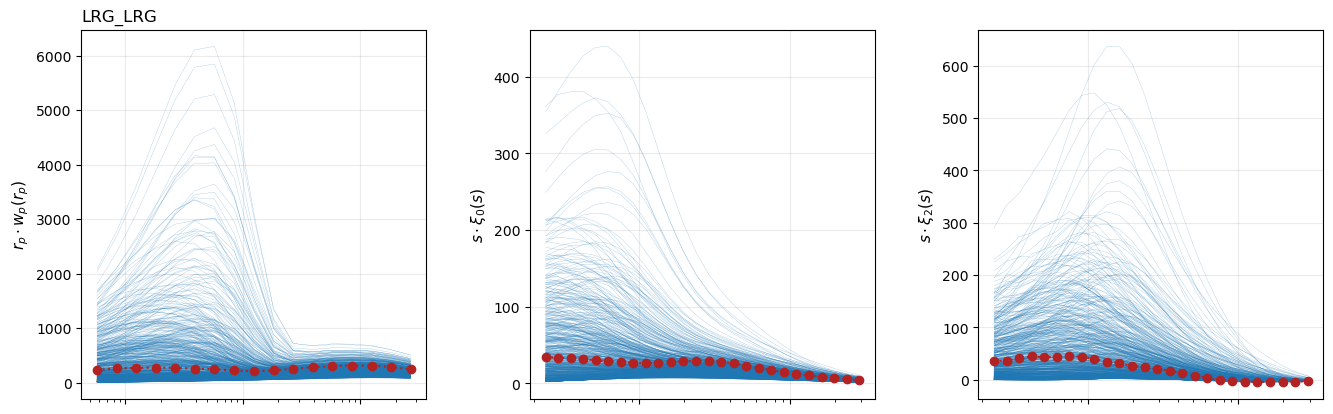

In [27]:
ff= plot_training_stats(train_Dataset, data=train_Dataset.y_test[0])

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py:508: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


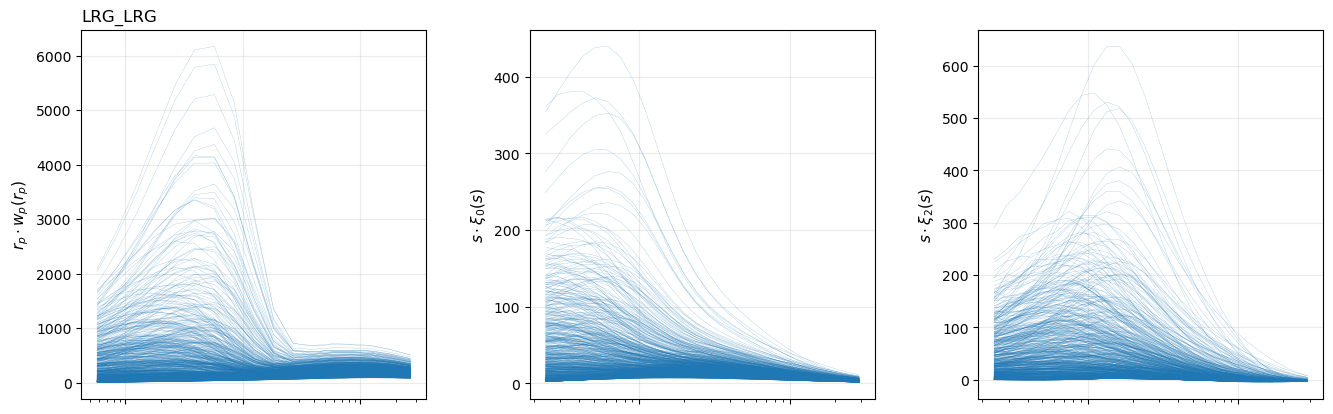

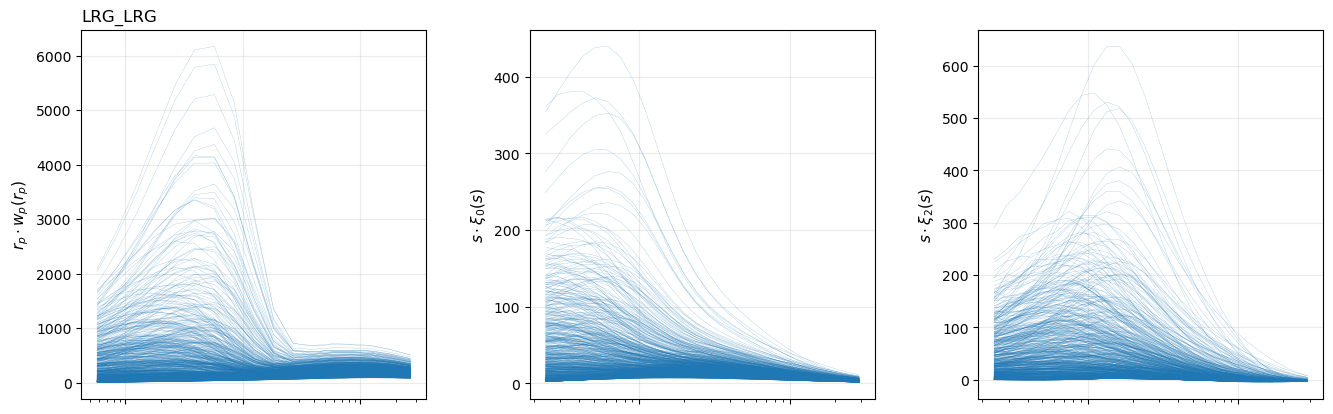

In [28]:
train_Dataset.plot_training_stats()

skew: -4.691570217026114 excess kurtosis: 65.24810213133928


(array([[-0.52605112, -0.22699267, -0.16448006, ..., -0.05417535,
         -0.01649318,  0.03010702],
        [-0.01364633,  0.01606055,  0.00950069, ..., -0.01733186,
         -0.04441221, -0.03382434],
        [-0.49626085, -0.36786212, -0.56726847, ...,  0.0117983 ,
         -0.09345779, -0.23612127],
        ...,
        [-0.11601972, -0.05543148,  0.03253497, ..., -0.04774172,
          0.03736966,  0.00597854],
        [ 0.03360926,  0.03642787,  0.01423634, ..., -0.01115873,
          0.01022144,  0.00317273],
        [-0.00671191, -0.01327138, -0.0215794 , ..., -0.01248937,
         -0.05024599, -0.02030211]], shape=(200, 69)),
 array([2.56431183e+02, 3.04287653e+02, 1.56522167e+02, 1.80364948e+02,
        1.64563764e+02, 2.28644194e+02, 6.67605327e+01, 3.08208689e+01,
        2.74919168e+01, 1.19775124e+01, 1.84557942e+00, 4.19575494e-01,
        3.66342502e-01, 2.23474353e-01, 1.80605288e-01, 9.11934560e-02,
        5.47272737e-02, 1.56421368e+01, 1.46638259e+01, 1.22818205e+

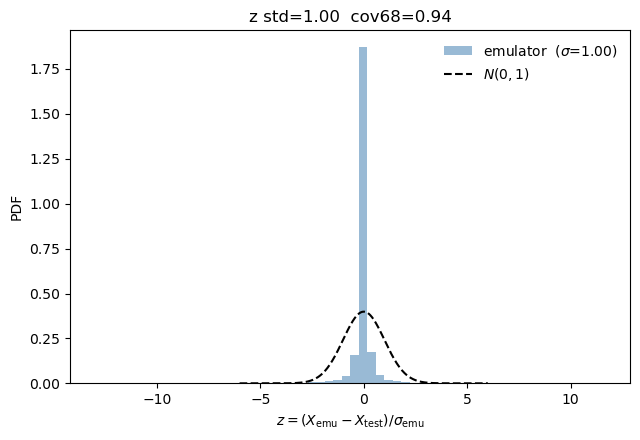

In [ ]:
import numpy as np
import torch

def zscore_from_cov(model, train_Dataset, use_red_prior=False, plot=True):
    """
    Z-score using the emulator error from the test-set covariance (SUNBIRD eq. 15),
    z_k = (X_emu - X_test) / sigma_emu,  sigma_emu = sqrt(diag(C_emu)).
    """
    B = train_Dataset.y_test.shape[1]

    if use_red_prior:
        q_lo, q_hi = np.quantile(train_Dataset.X_training, q=[0.01, 0.99], axis=0)
        mask = ((train_Dataset.X_test > q_lo) & (train_Dataset.X_test < q_hi)).all(axis=1)
    else:
        mask = np.ones(train_Dataset.x_test_norm.shape[0], dtype=bool)

    # predictions -> physical space
    X = torch.tensor(train_Dataset.x_test_norm[mask], dtype=torch.float32).to(model.device)
    y_pred_norm = model.predict(X, no_grad=True)[0].cpu().numpy().reshape(-1, B)
    X_emu, _ = train_Dataset.normalizer.denormalize_y(y_pred_norm, None)
    X_emu  = X_emu.reshape(-1, B)
    X_test = train_Dataset.y_test[mask].reshape(-1, B)

    # --- SUNBIRD eq. 15 covariance, then per-bin sigma ---
    dX = X_emu - X_test                              # (N, B)
    C_emu = np.cov(dX, rowvar=False, bias=False)     # (B, B)
    sigma_emu = np.sqrt(np.diag(C_emu))              # (B,)  one sigma per bin

    # --- z-score: broadcast the per-bin sigma across all samples ---
    Z = dX / sigma_emu                               # (N, B)

    info = {
        "z_std":       Z.std(),                      # SUNBIRD report ~1.16 for their CCF
        "z_mean":      Z.mean(),
        "coverage_68": np.mean(np.abs(Z) < 1),
        "coverage_95": np.mean(np.abs(Z) < 2),
    }

    if plot:
        import matplotlib.pyplot as plt
        z = Z.ravel()
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
        ax.hist(z, bins=60, density=True, alpha=0.55, color="steelblue",
                edgecolor="none", label=fr"emulator  ($\sigma$={info['z_std']:.2f})")
        xx = np.linspace(-6, 6, 400)
        ax.plot(xx, np.exp(-0.5*xx**2)/np.sqrt(2*np.pi), "k--", lw=1.5, label=r"$N(0,1)$")
        # ax.set_xlim(-6, 6)
        ax.set_xlabel(r"$z = (X_{\rm emu}-X_{\rm test})/\sigma_{\rm emu}$")
        ax.set_ylabel("PDF"); ax.legend(frameon=False)
        ax.set_title(f"z std={info['z_std']:.2f}  cov68={info['coverage_68']:.2f}")
        plt.tight_layout()
    from scipy.stats import skew, kurtosis
    print("skew:", skew(Z.ravel()), "excess kurtosis:", kurtosis(Z.ravel()))

    return Z, sigma_emu, info

zscore_from_cov(model, train_Dataset)

{'z_net_std': np.float64(1.1482042281538054), 'z_net_mean': np.float64(-0.04949966009725661), 'z_cov_std': np.float64(0.9998764299807839), 'z_cov_mean': np.float64(-0.0797304212784536), 'cov68_net': np.float64(0.7179710144927536), 'cov68_cov': np.float64(0.9391304347826087)}


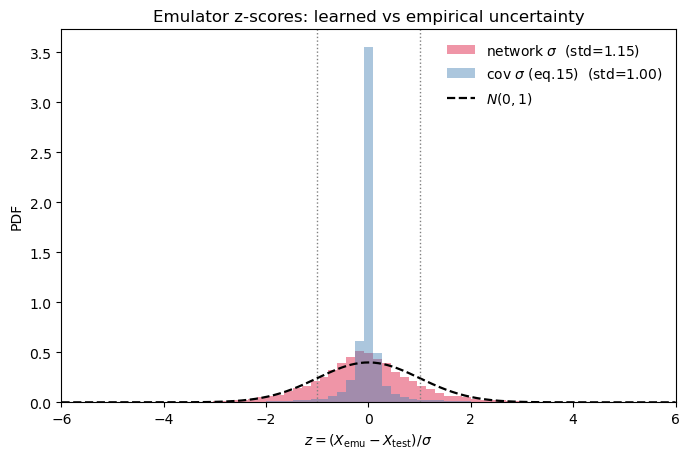

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def zscore_compare(model, train_Dataset, use_red_prior=False):
    """
    Overlay two z-score distributions against N(0,1):
      - network sigma (softplus head)  -> tests whether the LEARNED uncertainty is calibrated
      - covariance sigma (SUNBIRD eq15) -> tests residual Gaussianity / bias
    """
    B = train_Dataset.y_test.shape[1]

    if use_red_prior:
        q_lo, q_hi = np.quantile(train_Dataset.X_training, q=[0.01, 0.99], axis=0)
        mask = ((train_Dataset.X_test > q_lo) & (train_Dataset.X_test < q_hi)).all(axis=1)
    else:
        mask = np.ones(train_Dataset.x_test_norm.shape[0], dtype=bool)

    # predictions -> physical space (mean and variance)
    X = torch.tensor(train_Dataset.x_test_norm[mask], dtype=torch.float32).to(model.device)
    y_pred_norm, var_pred_norm = model.predict(X, no_grad=True)
    y_pred_norm   = y_pred_norm.cpu().numpy().reshape(-1, B)
    var_pred_norm = var_pred_norm.cpu().numpy().reshape(-1, B)

    X_emu, var_emu = train_Dataset.normalizer.denormalize_y(y_pred_norm, var_pred_norm)
    X_emu   = X_emu.reshape(-1, B)
    var_emu = var_emu.reshape(-1, B)
    X_test  = train_Dataset.y_test[mask].reshape(-1, B)

    dX = X_emu - X_test                                  # (N, B)

    # --- z with NETWORK sigma (per-sample, per-bin) ---
    sigma_net = np.sqrt(var_emu)                         # (N, B)
    Z_net = dX / sigma_net

    # --- z with COVARIANCE sigma (SUNBIRD eq.15, per-bin) ---
    C_emu = np.cov(dX, rowvar=False, bias=False)         # (B, B)
    sigma_cov = np.sqrt(np.diag(C_emu))                  # (B,)
    Z_cov = dX / sigma_cov                               # broadcast over samples

    # --- overlay plot ---
    fig, ax = plt.subplots(figsize=(7, 4.7))
    bins = np.linspace(-6, 6, 70)

    ax.hist(Z_net.ravel(), bins=bins, density=True, alpha=0.45, color="crimson",
            edgecolor="none", label=fr"network $\sigma$  (std={Z_net.std():.2f})")
    ax.hist(Z_cov.ravel(), bins=bins, density=True, alpha=0.45, color="steelblue",
            edgecolor="none", label=fr"cov $\sigma$ (eq.15)  (std={Z_cov.std():.2f})")

    xx = np.linspace(-6, 6, 400)
    ax.plot(xx, np.exp(-0.5*xx**2)/np.sqrt(2*np.pi), "k--", lw=1.6, label=r"$N(0,1)$")
    for s in (-1, 1):
        ax.axvline(s, color="grey", ls=":", lw=1)

    ax.set_xlim(-6, 6)
    ax.set_xlabel(r"$z = (X_{\rm emu}-X_{\rm test})/\sigma$")
    ax.set_ylabel("PDF")
    ax.legend(frameon=False)
    ax.set_title("Emulator z-scores: learned vs empirical uncertainty")
    plt.tight_layout()
    
    return {
        "z_net_std": Z_net.std(), "z_net_mean": Z_net.mean(),
        "z_cov_std": Z_cov.std(), "z_cov_mean": Z_cov.mean(),
        "cov68_net": np.mean(np.abs(Z_net) < 1),
        "cov68_cov": np.mean(np.abs(Z_cov) < 1),
    }
info = zscore_compare(model, train_Dataset)
print(info)

In [ ]:
import numpy as np
import torch


def build_emulator_correlation(model, train_Dataset, use_red_prior=False):
    """
    Fixed emulator correlation R_emu from test-set residuals (SUNBIRD eq. 15),
    physical space. Amplitude will come per-theta from var_pred later.
    """
    B = train_Dataset.y_test.shape[1]

    if use_red_prior:
        q_lo, q_hi = np.quantile(train_Dataset.X_training, q=[0.01, 0.99], axis=0)
        mask = ((train_Dataset.X_test > q_lo) & (train_Dataset.X_test < q_hi)).all(axis=1)
    else:
        mask = np.ones(train_Dataset.X_test.shape[0], dtype=bool)

    xt = torch.tensor(train_Dataset.x_test_norm[mask], dtype=torch.float32).to(train_Dataset.device)
    y_pred_norm = model.predict(xt, no_grad=True)[0].cpu().numpy().reshape(-1, B)
    X_emu, _ = train_Dataset.normalizer.denormalize_y(y_pred_norm, None)
    X_emu  = X_emu.reshape(-1, B)
    X_test = train_Dataset.y_test[mask].reshape(-1, B)

    dX = X_emu - X_test
    C_emu = np.cov(dX, rowvar=False, bias=False)
    d = np.sqrt(np.diag(C_emu))
    R_emu = C_emu / np.outer(d, d)
    R_emu = 0.5 * (R_emu + R_emu.T)              # symmetrize
    return R_emu


def _hybrid_cov(var_pred_phys, R_emu, C_data):
    """C(theta) = C_data + D R_emu D,  D = diag(sqrt(var_pred))."""
    D = np.sqrt(var_pred_phys)
    return C_data + (D[:, None] * D[None, :]) * R_emu


def _gaussian_loglike(resid, C):
    """-0.5 [ r^T C^-1 r + ln|C| ].  ln|C| REQUIRED (C depends on theta)."""
    L = np.linalg.cholesky(C)
    alpha = np.linalg.solve(L, resid)
    chi2 = alpha @ alpha
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return -0.5 * (chi2 + logdet)


def coverage_test(model, train_Dataset, R_emu, C_data,
                  param_names, prior_bounds,
                  n_test_points=None, use_red_prior=True,
                  n_samples=4000, add_data_noise=False,
                  credible_levels=np.linspace(0.05, 0.95, 19),
                  seed=0):
    """
    Simulation-based coverage test for the hybrid likelihood
    C(theta) = C_data + D(theta) R_emu D(theta).

    For each held-out test mock (known true theta, its data vector), build an
    importance-sampled posterior and check whether the truth lands inside each
    central credible interval. Empirical coverage ~ nominal => calibrated.
    """
    rng = np.random.default_rng(seed)
    B = train_Dataset.y_test.shape[1]
    P = len(param_names)
    prior_bounds = np.asarray(prior_bounds, float)          # (P, 2)

    # held-out test points
    theta_true_all = train_Dataset.X_test                   # (M, P) physical params
    Y_test_all     = train_Dataset.y_test                   # (M, B) physical data vectors

    if use_red_prior:
        q_lo, q_hi = np.quantile(train_Dataset.X_training, q=[0.01, 0.99], axis=0)
        keep = ((theta_true_all > q_lo) & (theta_true_all < q_hi)).all(axis=1)
    else:
        keep = np.ones(theta_true_all.shape[0], dtype=bool)
    theta_true_all, Y_test_all = theta_true_all[keep], Y_test_all[keep]

    M = theta_true_all.shape[0]
    if n_test_points is not None:
        sel = rng.choice(M, size=min(n_test_points, M), replace=False)
        theta_true_all, Y_test_all = theta_true_all[sel], Y_test_all[sel]
        M = theta_true_all.shape[0]

    # optional Cholesky of C_data for adding realistic noise to the mock "data"
    L_data = np.linalg.cholesky(C_data) if add_data_noise else None

    def emu_predict_phys(theta_phys):
        """(K, P) physical params -> mean (K, B), var (K, B) physical."""
        theta_norm = train_Dataset.normalizer.normalize_x(theta_phys)
        xt = torch.tensor(theta_norm, dtype=torch.float32).to(train_Dataset.device)
        m_norm, v_norm = model.predict(xt, no_grad=True)
        m_norm = m_norm.cpu().numpy().reshape(-1, B)
        v_norm = v_norm.cpu().numpy().reshape(-1, B)
        m_phys, v_phys = train_Dataset.normalizer.denormalize_y(m_norm, v_norm)
        return m_phys.reshape(-1, B), v_phys.reshape(-1, B)

    def weighted_quantile(values, weights, q):
        order = np.argsort(values)
        v, cw = values[order], np.cumsum(weights[order])
        cw /= cw[-1]
        return np.interp(q, cw, v)

    inside = np.zeros((len(credible_levels), P))
    ess_list = []

    for k in range(M):
        X_obs = Y_test_all[k].copy()
        if add_data_noise:
            X_obs = X_obs + L_data @ rng.standard_normal(B)
        theta_true = theta_true_all[k]

        # importance sampling from the flat prior
        theta_prop = rng.uniform(prior_bounds[:, 0], prior_bounds[:, 1], size=(n_samples, P))
        m_phys, v_phys = emu_predict_phys(theta_prop)

        logw = np.empty(n_samples)
        for i in range(n_samples):
            C = _hybrid_cov(v_phys[i], R_emu, C_data)
            logw[i] = _gaussian_loglike(X_obs - m_phys[i], C)

        logw -= logw.max()
        w = np.exp(logw); w /= w.sum()
        ess_list.append(1.0 / np.sum(w**2))                 # effective sample size

        for p in range(P):
            vals = theta_prop[:, p]
            for j, lvl in enumerate(credible_levels):
                lo = weighted_quantile(vals, w, 0.5 - lvl / 2)
                hi = weighted_quantile(vals, w, 0.5 + lvl / 2)
                if lo <= theta_true[p] <= hi:
                    inside[j, p] += 1

    empirical = inside / M
    ess = np.array(ess_list)

    # plot
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="perfect")
    for p in range(P):
        ax.plot(credible_levels, empirical[:, p], marker="o", ms=3, label=param_names[p])
    band = np.sqrt(credible_levels * (1 - credible_levels) / M)
    ax.fill_between(credible_levels, credible_levels - band, credible_levels + band,
                    color="grey", alpha=0.2, label="MC error")
    ax.set_xlabel("nominal credible level"); ax.set_ylabel("empirical coverage")
    ax.set_title(f"Coverage test  (M={M}, median ESS={np.median(ess):.0f})")
    ax.legend(fontsize=7, ncol=2, frameon=False)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    plt.tight_layout()

    return {
        "credible_levels": credible_levels,
        "empirical_coverage": empirical,
        "param_names": param_names,
        "n_test_mocks": M,
        "ess": ess,
    }

In [ ]:
R_emu = build_emulator_correlation(model, train_Dataset)

result = coverage_test(
    model, train_Dataset,
    R_emu=R_emu,
    C_data=C_data,                          # (B, B) physical space, same bin order as y_test
    param_names=[...],                      # length = train_Dataset.X_test.shape[1]
    prior_bounds=[[lo, hi], ...],           # per-parameter flat prior ranges
    n_test_points=200,
    n_samples=4000,
    add_data_noise=False,                   # True for the more realistic noisy-mock version
)
print("empirical coverage:\n", result["empirical_coverage"])
print("median ESS:", np.median(result["ess"]))

NameError: name 'C_data' is not defined

In [ ]:
import glob
from pycorr import TwoPointCorrelationFunction, utils
import os 


def get_corr_small_boxes(zsim, corr, parent_dir='/global/cfs/cdirs/desi/users/arocher/HODDIES_results/Abcaus_small_boxes_corr', pimax=40, ells=[0,2], show=False, return_cov=False):
    wp, xi = None, None
    files = os.path.join(parent_dir, 'z{zsim:.3f}/{{}}/allcounts_*.npy'.format(zsim=zsim))
    num_sim = len(glob.glob(files.format(corr[0])))
    if 'rppi' in corr:
        print(f'Loading rppi correlation function for z={zsim}...')
        wp = [TwoPointCorrelationFunction.load(file)[::2][4:-3](pimax=pimax) for file in glob.glob(files.format('rppi'))]

    if 'smu' in corr:
        print(f'Loading smu correlation function for z={zsim}...')
        xi = [np.hstack(TwoPointCorrelationFunction.load(file)[16:-6](ells=ells)) for file in glob.glob(files.format('smu'))]
        
    if wp is None:
        cov = np.cov(xi, rowvar=False, ddof=1) 
        corr = utils.cov_to_corrcoef(cov)
    elif xi is None:
        cov = np.cov(wp, rowvar=False, ddof=1)  
        corr = utils.cov_to_corrcoef(cov)
    else:
        cov = np.cov(np.hstack((wp,xi)), rowvar=False, ddof=1)
        corr = utils.cov_to_corrcoef(cov)
    if show:
        plt.imshow(corr)
    if return_cov:
        return cov, num_sim
    return corr


In [17]:
import emcee 
import glob
from HODDIES.fit_functions import get_hartlap_factor
from HODDIES.desi_utils import get_corr_small_boxes
import numpy as np

files = glob.glob('/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/mock_data/*')
files.sort()
ii = 22

mock_data_dict = np.load(files[ii], allow_pickle=True)[()]
data_vec = np.hstack([mock_data_dict['wp']['LRG_LRG'][-1][0], np.hstack(mock_data_dict['xi_ells']['LRG_LRG'][-1].reshape(20,2,26)[0])])
err_data_vec = np.hstack([mock_data_dict['wp']['LRG_LRG'][-1].std(axis=0), np.hstack(mock_data_dict['xi_ells']['LRG_LRG'][-1].reshape(20,2,26).std(axis=0))])

mcov, num_sim = get_corr_small_boxes(zsim=0.5, corr=['rppi', 'smu'], pimax=40, ells=[0,2], return_cov=True)
mcov = mcov/64

std_data = np.sqrt(np.diag(mcov))

x_truth = mock_data_dict['hod_fit_param'].tolist()

n_dim = len(x_truth)
n_chain = 20
priors = np.vstack([train_Dataset.X_training.min(axis=0), np.round(train_Dataset.X_training.max(axis=0), 2)]).T
pos = np.array([np.random.uniform(l, h, size=n_chain) for l, h in priors]).T


Loading rppi correlation function for z=0.5...
Loading smu correlation function for z=0.5...


In [18]:
from pycorr import utils
hartlap_fac = get_hartlap_factor(num_sim, len(mcov))
corr = utils.cov_to_corrcoef(mcov)
sig_data = np.sqrt(np.diag(mcov) + err_data_vec**2)

sign, logdet_corr_data = np.linalg.slogdet(corr)

Mcov_data = corr*sig_data*sig_data[:,None]
# inv_cov2 = np.linalg.inv(Mcov_data/(1-hartlap_fac))
inv_corr_data = np.linalg.inv(corr)

In [19]:
from HODDIES.fit_functions.fits_functions import values_in_boundaries, likelihood
import time 

def likelihood_vec(thetas, model, data, priors, inv_corr_data, sig_data_err, logdet_corr_data=0.0):
    thetas = np.atleast_2d(thetas)
    inside = np.array([values_in_boundaries(t, priors) for t in thetas])

    theta_norm = train_Dataset.normalizer.normalize_x(thetas)
    xt = torch.tensor(theta_norm, dtype=torch.float32).to(train_Dataset.device)
    y_pred_norm, var_pred_norm = model.predict(xt, no_grad=True)
    Y_pred, var_pred = train_Dataset.normalizer.denormalize_y(
        y_pred_norm.cpu().numpy(), var_pred_norm.cpu().numpy())

    delta = Y_pred - data                                    # (n, B)
    std_tot = np.sqrt(var_pred + sig_data_err**2)            # (n, B)

    # per-walker chi2 with per-walker std rescaling of the fixed inv correlation
    # chi2_n = sum_ij delta_ni * inv_corr_ij * delta_nj / (std_tot_ni * std_tot_nj)
    d_scaled = delta / std_tot                               # fold D_tot^-1 into delta
    chi2 = np.einsum('ni,ij,nj->n', d_scaled, inv_corr_data, d_scaled)   # (n,)

    logdet = logdet_corr_data + 2.0 * np.sum(np.log(std_tot), axis=1)    # (n,)
    logl = -0.5 * (chi2 + logdet)
    logl[~inside] = -np.inf
    return logl


sampler = emcee.EnsembleSampler(n_chain, n_dim, likelihood, args=(model, train_Dataset, data_vec, priors, None, inv_corr_data, sig_data, logdet_corr_data))

# On GPU
# sampler = emcee.EnsembleSampler(
#     n_chain, n_dim, likelihood_vec,
#     args=(model, mock_data_y, priors, inv_cov2),
#     vectorize=True,
# )
n_point = 5000
start = time.time()
sampler.run_mcmc(pos, n_point, progress=True)
end = time.time()
serial_time = end - start

  6%|▋         | 314/5000 [02:03<35:07,  2.22it/s]Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/fits_functions.py", line 224, in likelihood
    y_pred_norm, var_pred_norm = model.predict(theta_tensor, no_grad=True)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py", line 744, in predict
    preds, var = self.forward(X)
                 ^^^^^^^^^^^^^^^
  File "/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/FCNN_utils.py", line 667, in forward
    var = nn.functional.softplus(log_var)
         ^^^^^^^^^^^^^^^

emcee: Exception while calling your likelihood function:
  params: [13.49964592 14.49631751  1.05667503  1.13109633 13.19159519  0.24803312]
  args: (FCNN(
  (model): Sequential(
    (mlp0): Linear(in_features=6, out_features=755, bias=True)
    (act0): SiLU()
    (dropout0): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp1): Linear(in_features=755, out_features=906, bias=True)
    (act1): SiLU()
    (dropout1): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp2): Linear(in_features=906, out_features=672, bias=True)
    (act2): SiLU()
    (dropout2): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp3): Linear(in_features=672, out_features=909, bias=True)
    (act3): SiLU()
    (dropout3): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp4): Linear(in_features=909, out_features=804, bias=True)
    (act4): SiLU()
    (dropout4): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp5): Linear(in_features=804, out_features=138, bias=True)
  )
  (loss_fn): G

KeyboardInterrupt: 

In [ ]:
import time
from multiprocessing import Pool, get_context
import torch 
import os 
n_threads = 1
torch.set_num_threads(n_threads)
os.environ['OMP_NUM_THREADS'] = str(n_threads)

ctx = get_context('spawn')
with ctx.Pool(processes=32) as pool:
    sampler = emcee.EnsembleSampler(n_chain, n_dim, likelihood, args=(model, train_Dataset, data_vec, priors, None, inv_corr_data, sig_data, logdet_corr_data), pool=pool)
    print("Running MCMC with multiprocessing...")
    start = time.time()
    sampler.run_mcmc(pos, n_point, progress=True)
    end = time.time()
    multi_time = end - start
    print("Multiprocessing took {0:.1f} seconds".format(multi_time))
    print("{0:.1f} times faster than serial".format(serial_time / multi_time))

Running MCMC with multiprocessing...


  2%|▏         | 91/5000 [00:16<15:10,  5.39it/s]Process SpawnPoolWorker-35:
Process SpawnPoolWorker-31:
Process SpawnPoolWorker-34:
  2%|▏         | 91/5000 [00:16<14:48,  5.53it/s]Process SpawnPoolWorker-33:
Process SpawnPoolWorker-30:
Process SpawnPoolWorker-36:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/pool.p

emcee: Exception while calling your likelihood function:
  params: emcee: Exception while calling your likelihood function:
  params: [12.58042521 13.51342666  0.55044368  0.55616248 12.96211041  0.85511538]
  args: [12.50248327 13.59969764  0.65309663  0.55438854 13.09414464  0.90687129]
  args: (FCNN(
  (model): Sequential(
    (mlp0): Linear(in_features=6, out_features=755, bias=True)
    (act0): SiLU()
    (dropout0): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp1): Linear(in_features=755, out_features=906, bias=True)
    (act1): SiLU()
    (dropout1): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp2): Linear(in_features=906, out_features=672, bias=True)
    (act2): SiLU()
    (dropout2): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp3): Linear(in_features=672, out_features=909, bias=True)
    (act3): SiLU()
    (dropout3): Dropout(p=8.907192912237022e-05, inplace=False)
    (mlp4): Linear(in_features=909, out_features=804, bias=True)
    (act4): SiLU(


ssing/queues.py", line 386, in get
    with self._rlock:
         ^^^^^^^^^^^
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/

BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
# Option B: multiprocessing - for a CPU emulator
# ==========================================================================
# The model is held in a module-level global, populated once per worker by the
# initializer. Passing it through `args` instead would re-pickle the whole
# network on every single likelihood call, which usually costs more than the
# evaluation itself.
_G = {}



def _init_worker(model, train_Dataset, n_threads=1):
    """Runs once per worker process."""
    # Without this each worker spawns its own BLAS thread pool and they fight
    # over the same cores.
    torch.set_num_threads(n_threads)
    os.environ['OMP_NUM_THREADS'] = str(n_threads)

    _G['model']   = model
    _G['dataset'] = train_Dataset


def _logl(theta, data, priors, inv_corr_data, sig_data, logdet_corr_data):
    """Picklable top-level wrapper; reads the model from the worker global."""
    return likelihood(theta, _G['model'], _G['dataset'], data, priors,        
                      None, inv_corr_data, sig_data, logdet_corr_data)
 
 
def run_multiprocessing(pos, n_point, model, train_Dataset, data_vec,
                        priors, inv_corr_data, sig_data, logdet_corr_data,
                        n_proc=32):
    from multiprocessing import get_context
 
    n_chain, n_dim = pos.shape
 
    # 'spawn' rather than 'fork': forking a process that has already touched
    # CUDA, or holds torch's thread pool, leads to deadlocks and silent hangs.
    ctx = get_context('spawn')
 
    with ctx.Pool(processes=n_proc,
                  initializer=_init_worker,
                  initargs=(model, train_Dataset)) as pool:
 
        sampler = emcee.EnsembleSampler(
            n_chain, n_dim, _logl,
            args=(data_vec, priors, inv_corr_data, sig_data, logdet_corr_data),
            pool=pool)
 
        sampler.run_mcmc(pos, n_point, progress=True)
 
    return sampler


In [ ]:
n_point = 5000

run_multiprocessing(pos, n_point, model, train_Dataset, data_vec,
                   priors, inv_corr_data, sig_data, logdet_corr_data, n_proc=32)

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute '_init_worker' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>


KeyboardInterrupt: 

Process ForkPoolWorker-54:
Traceback (most recent call last):
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
Process ForkPoolWorker-55:
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/c

KeyboardInterrupt: 

In [62]:
import emcee 
import glob
from HODDIES.fit_functions.fits_functions import get_hartlap_factor
from HODDIES.desi_utils import get_corr_small_boxes

files = glob.glob('/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/mock_data/*')
files.sort()
ii = 1

mock_data_dict = np.load(files[ii], allow_pickle=True)[()]
data_vec = np.hstack([mock_data_dict['wp']['LRG_LRG'][-1][0], np.hstack(mock_data_dict['xi_ells']['LRG_LRG'][-1].reshape(20,2,26)[0])])
err_data_vec = np.hstack([mock_data_dict['wp']['LRG_LRG'][-1].std(axis=0), np.hstack(mock_data_dict['xi_ells']['LRG_LRG'][-1].reshape(20,2,26).std(axis=0))])


std_data = np.sqrt(np.diag(mcov))

x_truth = mock_data_dict['hod_fit_param'].tolist()

n_dim = len(x_truth)
n_chain = 20
priors = np.vstack([train_Dataset.X_training.min(axis=0), np.round(train_Dataset.X_training.max(axis=0), 2)]).T
pos = np.array([np.random.uniform(l, h, size=n_chain) for l, h in priors]).T


❌ Chains not converged


Parameter $\log M_{\mathrm{cent}}$ in chain an emcee chain is not constrained
Parameter $\sigma_M$ in chain an emcee chain is not constrained


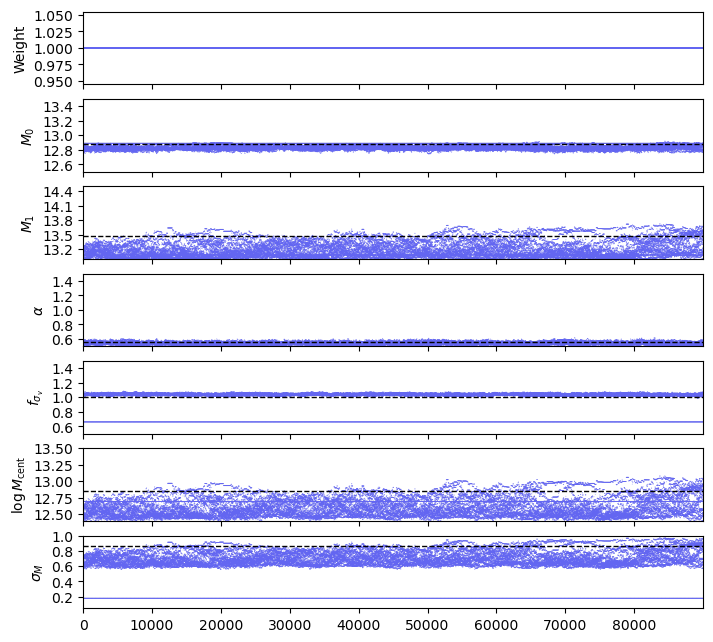

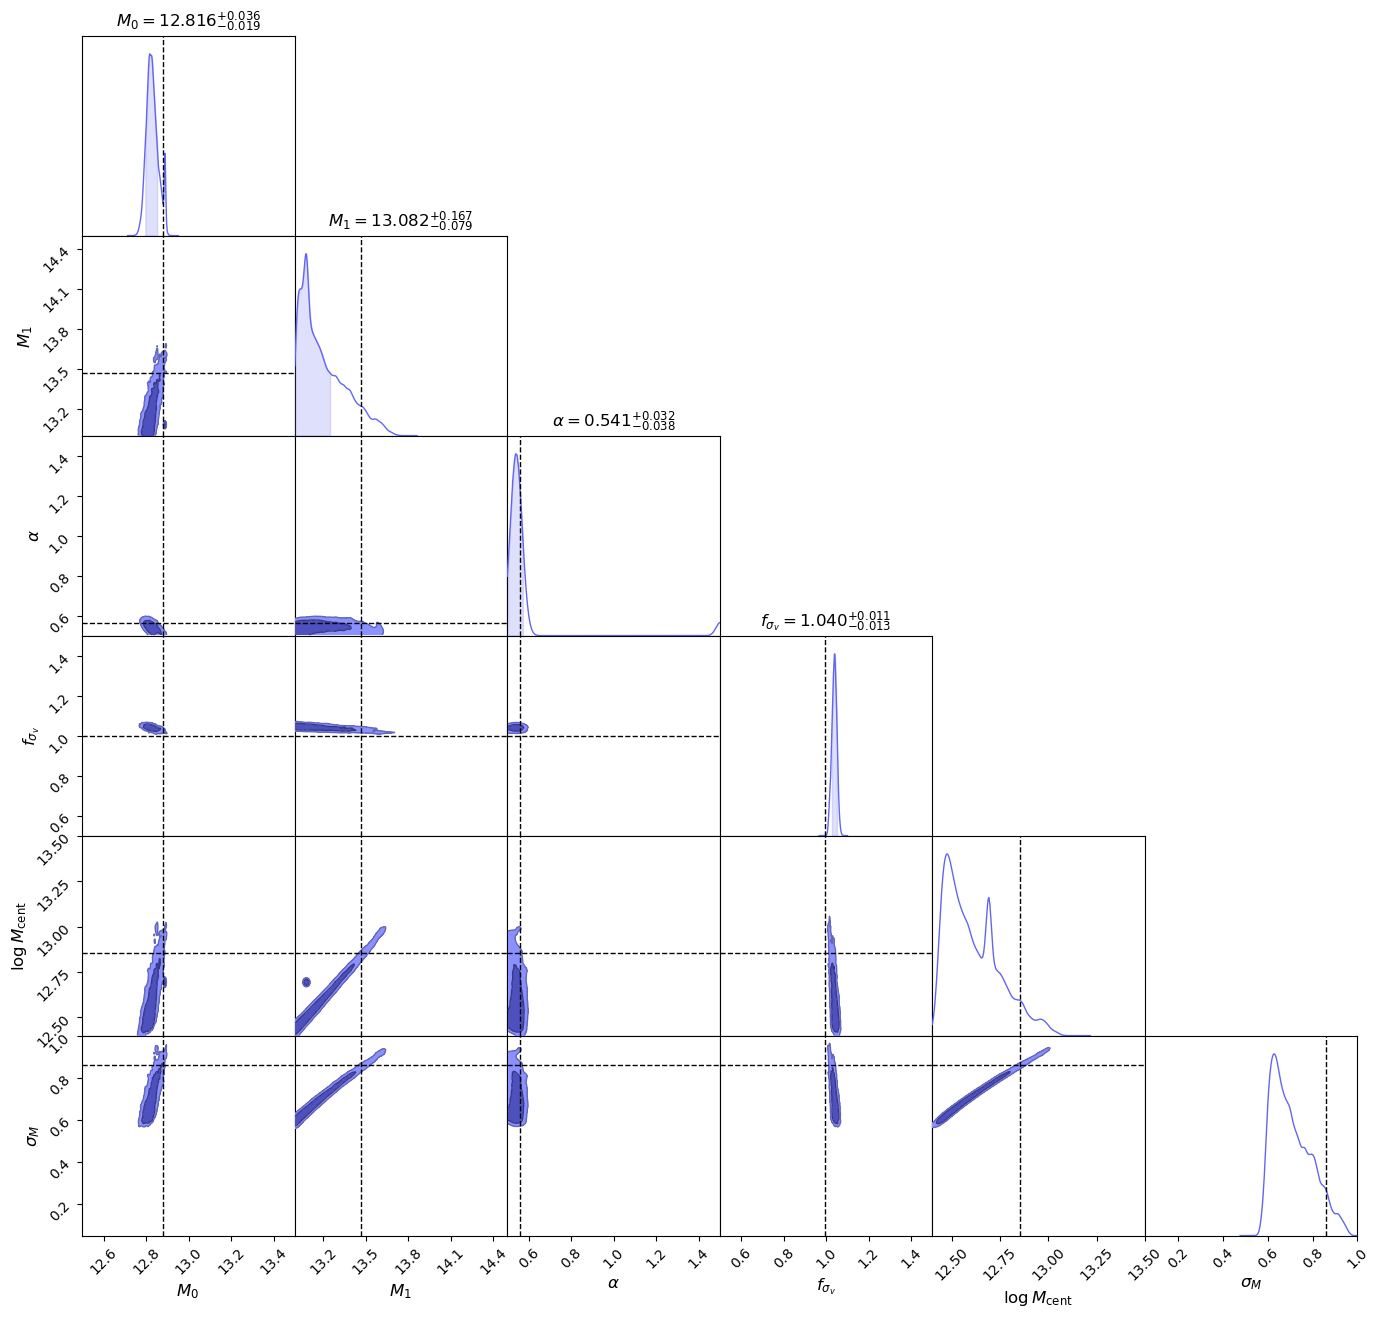

In [ ]:
from chainconsumer import Chain, ChainConsumer, Truth

param_labels = {
    "Ac": r"$A_c$",
    "As": r"$A_s$",
    "M_0": r"$M_0$",
    "M_1": r"$M_1$",
    "Q": r"$Q$",
    "alpha": r"$\alpha$",
    # --- assembly bias parameters ---
    "ab_c_cen": r"$A_{B,\,c}^{\mathrm{cen}}$",
    "ab_c_sat": r"$A_{B,\,c}^{\mathrm{sat}}$",
    "ab_env_cen": r"$A_{B,\,\mathrm{env}}^{\mathrm{cen}}$",
    "ab_env_sat": r"$A_{B,\,\mathrm{env}}^{\mathrm{sat}}$",
    # --- other model parameters ---
    "f_sigv": r"$f_{\sigma_v}$",
    "gamma": r"$\gamma$",
    "log_Mcent": r"$\log M_{\mathrm{cent}}$",
    "pmax": r"$p_{\max}$",
    "sigma_M": r"$\sigma_M$",
    "exp_frac": r"$f_{\exp}$",
    "exp_scale": r"$s_{\exp}$",
    "nfw_rescale": r"$\lambda_{\mathrm{NFW}}$",
    "v_infall": r"$v_{\mathrm{infall}}$",
    "v_smear": r"$v_{\mathrm{smear}}$"
}

chain_name = "an emcee chain"
name_params = [param_labels[par[:-4]] for par in train_Dataset.name_arr]
sampler = np.load('/global/cfs/cdirs/desi/users/arocher/HODDIES_results/test/AbacusSummit_base_c000_ph000/z0.500/mcmc_results/mcmc_results_0.5_AbacusSummit_base_c000_ph001_1.npy', allow_pickle=True)[()]
chain = Chain.from_emcee(sampler, name_params, chain_name, discard=1000, thin=2, color="indigo", extents=dict(zip(name_params, priors)), walkers=20)


consumer = ChainConsumer().add_chain(chain)
consumer.plotter.config.extents = dict(zip(name_params, priors))
consumer.add_truth(Truth(location=dict(zip(name_params, x_truth))))


if consumer.diagnostic.gelman_rubin(threshold=0.01):
    print('✅ Chains converged')
else:
    print('❌ Chains not converged')
fig = consumer.plotter.plot_walks()
fig = consumer.plotter.plot()

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:627: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


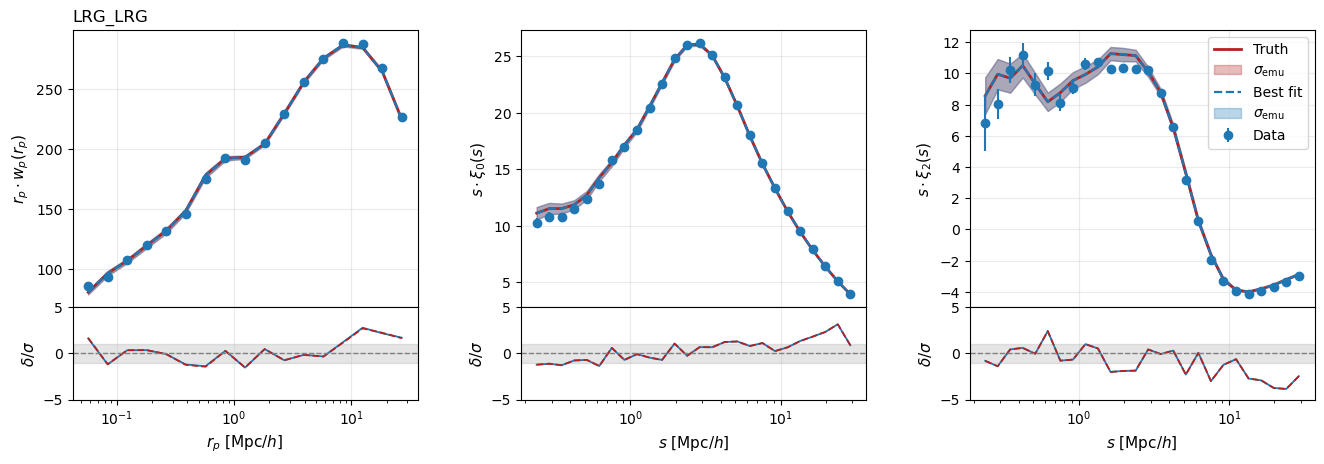

/global/u1/a/arocher/Code/postdoc/HODDIES_v2/HODDIES/HODDIES/fit_functions/plotting_emulator_func.py:630: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


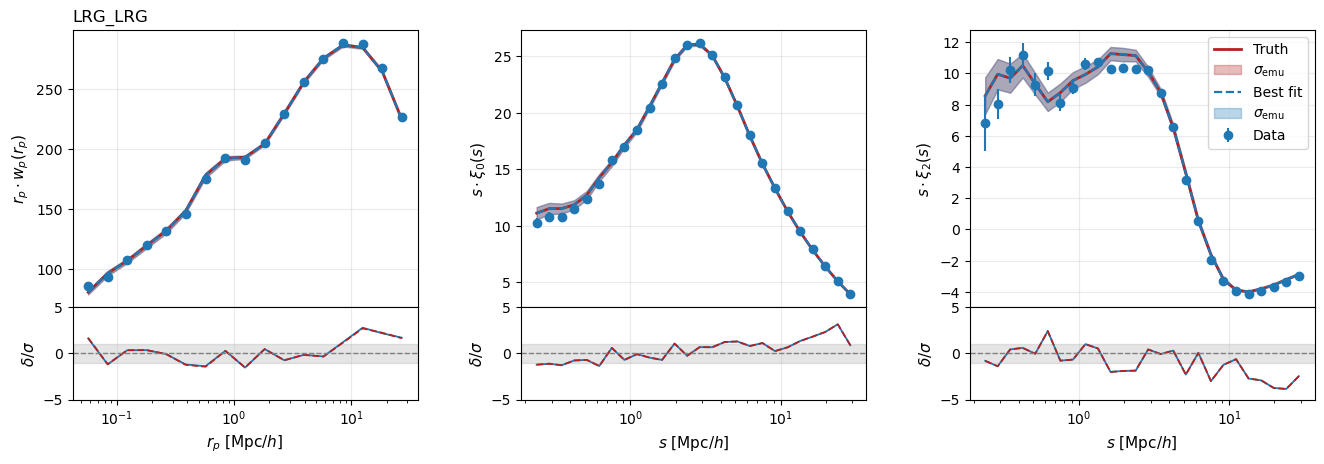

In [20]:
from HODDIES.fit_functions.plotting_emulator_func import plot_bf_results
# summary = consumer.analysis.get_summary()
# bound = summary[chain_name]
# # print(bound.center)                 # median
# # print(bound.lower, bound.upper)     # 16th/84th by default
# x_best_fit = [bound[key].center for key in name_params]

plot_bf_results(train_Dataset, model, x_truth, data_vec, err_data_vec,x_truth=x_truth, save_fn='test_bf_plot.png')

In [66]:
x_truth = mock_data_dict['hod_fit_param'].tolist()

In [67]:
49/(len(data_vec)-6)

0.7777777777777778

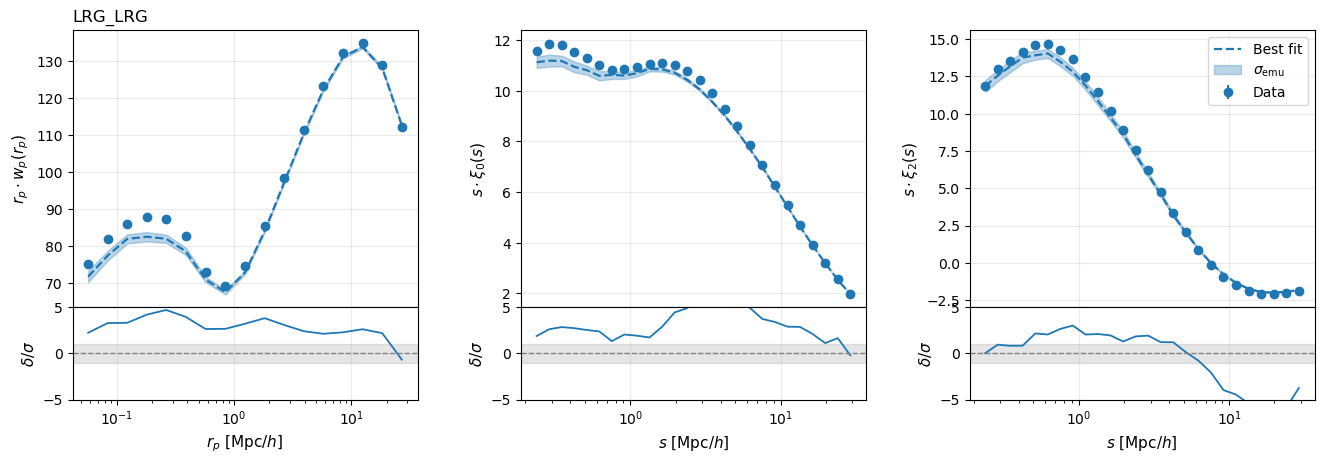

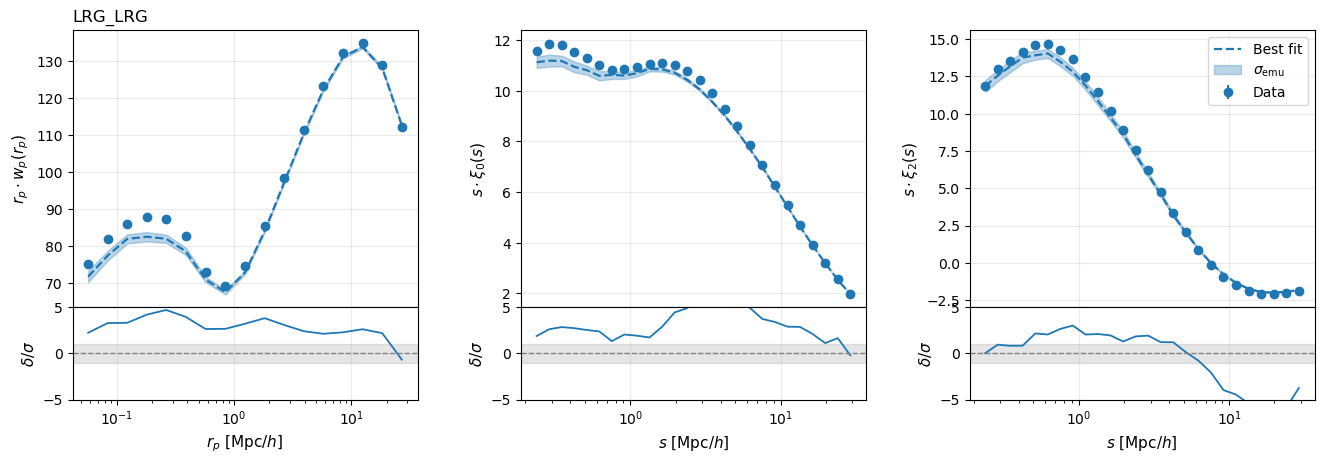

In [68]:
import matplotlib.pyplot as plt
plot_data(train_Dataset, model, x_best_fit, data_vec, err_data_vec, get_LH=False)

In [ ]:
from sim_loader.abacus_io import AbacusSummitSim
from HODDIES.hod import HOD
# from sim_loader import setup_logging
import numpy as np
import matplotlib.pyplot as plt
# setup_logging()
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/dvs_ro/cfs/cdirs/desi/cosmosim/Abacus',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': False,  # Whether to load particle/subhalos data
}
test=AbacusSummitSim(**default_abacus_param)

HOD_obj = HOD(base_catalog=test, tracers='LRG', setup_logger=False)


[000000.00]  09-01 06:00 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.03]  09-01 06:00 AbacusSummitSim              INFO     Load Compaso catalogue from /dvs_ro/cfs/cdirs/desi/cosmosim/Abacus/small/AbacusSummit_small_c000_ph3000/halos/z0.500 ...
[000003.42]  09-01 06:00 AbacusSummitSim              INFO     Done took 00:00:03
[000003.44]  09-01 06:00 AbacusSummitSim              INFO     Compute required columns...
[000004.04]  09-01 06:00 AbacusSummitSim              INFO     Done took 00:00:00
setup_logger False
[000007.41]  09-01 06:00 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


In [ ]:
cat = HOD_obj.make_mock_cat()

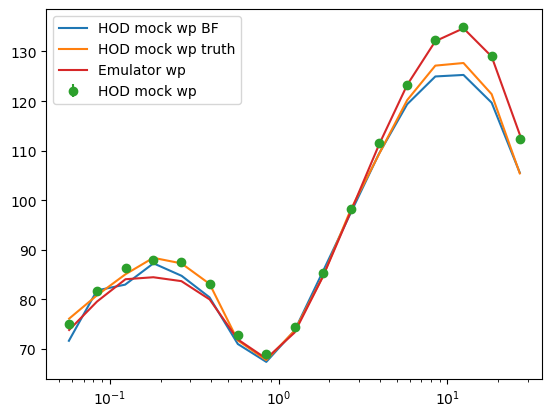

In [ ]:
for key, value in zip(HOD_obj.args['fit_param']['priors']['LRG'].keys(), x_best_fit):
    HOD_obj.args['LRG'][key] = value

HOD_obj.args['LRG']['density'] = None
cat = HOD_obj.make_mock_cat()

HOD_obj.args['clustering_settings']['xi_rppi']['edges_rppi'] = TwoPointCorrelationFunction.load('/global/cfs/cdirs/desi/users/arocher/Y1/2PCF_for_corr/Abcaus_small_boxes/z0.500/rppi/allcounts_LRG_AbacusSummit_small_c000_ph3000.npy')[::2][4:-3].edges
rp, wp = HOD_obj.get_wp(cat)

plt.semilogx(rp, rp*wp, label='HOD mock wp BF')


for key, value in zip(HOD_obj.args['fit_param']['priors']['LRG'].keys(), x_truth):
    HOD_obj.args['LRG'][key] = value

HOD_obj.args['LRG']['density'] = None
cat = HOD_obj.make_mock_cat()

HOD_obj.args['clustering_settings']['xi_rppi']['edges_rppi'] = TwoPointCorrelationFunction.load('/global/cfs/cdirs/desi/users/arocher/Y1/2PCF_for_corr/Abcaus_small_boxes/z0.500/rppi/allcounts_LRG_AbacusSummit_small_c000_ph3000.npy')[::2][4:-3].edges
rp, wp = HOD_obj.get_wp(cat)

plt.semilogx(rp, rp*wp, label='HOD mock wp truth')


plt.errorbar(rp, rp*data_vec[:17], rp*err_data_vec[:17], fmt='o', label='HOD mock wp')

x_norm_bf = torch.tensor(train_Dataset.normalizer.normalize_x(x_best_fit), dtype=torch.float32)
Y_pred_bf, var_pred_bf = model.predict(x_norm_bf, no_grad=True)
Y_pred_bf, var_pred_bf = train_Dataset.normalizer.denormalize_y(
Y_pred_bf.cpu().numpy(), var_pred_bf.cpu().numpy())
err_pred_bf = np.sqrt(np.asarray(var_pred_bf))

plt.semilogx(rp, rp*Y_pred_bf[:17], label='Emulator wp')

plt.legend()

In [ ]:
err_data_vec

array([1.31752727e+02, 5.50468331e+01, 3.83590953e+01, 1.60956612e+01,
       1.05327586e+01, 7.49072099e+00, 3.88753767e+00, 1.92196178e+00,
       1.38876599e+00, 9.92238035e-01, 4.32846965e-01, 3.37863604e-01,
       2.17383314e-01, 1.89809866e-01, 1.43364247e-01, 1.20559066e-01,
       9.46239760e-02, 9.50149998e+00, 5.46905045e+00, 4.45846495e+00,
       2.58551255e+00, 1.22181399e+00, 1.32180377e+00, 4.66964004e-01,
       4.58320446e-01, 2.44693036e-01, 1.82551776e-01, 9.68598544e-02,
       5.92423542e-02, 4.66016152e-02, 3.69764682e-02, 3.23384390e-02,
       1.45726550e-02, 1.23447888e-02, 9.46899359e-03, 6.50165936e-03,
       5.76173984e-03, 4.04944989e-03, 2.98090949e-03, 2.54451798e-03,
       2.19051458e-03, 1.57858620e-03, 1.46681455e-03, 3.01242202e+01,
       2.06863403e+01, 1.39292199e+01, 6.28951629e+00, 5.91623810e+00,
       3.77210382e+00, 1.94102294e+00, 2.11022381e+00, 7.88096117e-01,
       6.03905348e-01, 4.62194253e-01, 2.69936581e-01, 1.95810416e-01,
      

In [52]:
import torch 
def plot_data(train_Dataset, model, x_best_fit, data_vec, err_data_vec,x_truth=None, stats=None,
               show_normalized=False, get_LH=False,
               max_cols=4,
               fontsize=11, residual_ylim=(-5, 5), block_hspace=0.55,
               wspace=0.30, height_ratios=(3, 1), colors=None, show=True):
    """Compare emulator predictions with the test set.

    One figure per test sample, one row of panels per tracer, wrapped at
    ``max_cols`` columns, with a ``(truth - prediction)/sigma`` sub-panel
    flush beneath each panel.

    Parameters
    ----------
    train_Dataset : Training_DatasetManager
        Must expose ``slices``; ``coords`` (see note in the module
        docstring) is needed to split multipole blocks into panels.
    model : object with ``predict``
    stats : sequence of str or None
        Restrict to these statistics. ``None`` plots everything in
        ``slices``.
    indices : sequence of int or None
        Explicit test-set indices to plot.
    """
    # ---- predictions -------------------------------------------------
    if x_truth is not None:
        x_norm_truth = torch.tensor(train_Dataset.normalizer.normalize_x(x_truth), dtype=torch.float32)
        Y_pred_truth, var_pred_truth = model.predict(x_norm_truth, no_grad=True)
        if not show_normalized:
            Y_pred_truth, var_pred_truth = train_Dataset.normalizer.denormalize_y(
                Y_pred_truth.cpu().numpy(), var_pred_truth.cpu().numpy())
        else:
            Y_pred_truth = np.asarray(Y_pred_truth.cpu().numpy())
            var_pred_truth = np.asarray(var_pred_truth.cpu().numpy())
        err_pred_truth = np.sqrt(np.asarray(var_pred_truth))

    x_norm_bf = torch.tensor(train_Dataset.normalizer.normalize_x(x_best_fit), dtype=torch.float32)
    Y_pred_bf, var_pred_bf = model.predict(x_norm_bf, no_grad=True)
    if not show_normalized:
        Y_pred_bf, var_pred_bf = train_Dataset.normalizer.denormalize_y(
            Y_pred_bf.cpu().numpy(), var_pred_bf.cpu().numpy())
    else:
        Y_pred_bf = np.asarray(Y_pred_bf.cpu().numpy())
        var_pred_bf = np.asarray(var_pred_bf.cpu().numpy())
    err_pred_bf = np.sqrt(np.asarray(var_pred_bf))
        
    # ---- panels ------------------------------------------------------
    from HODDIES.fit_functions.plotting_emulator_func import _plot_2d_residual, _ylabel, _panels
    panels = _panels(train_Dataset, stats)
    if not panels:
        raise ValueError(
            f'no panels for stats={stats}; available slices: '
            f'{sorted(train_Dataset.slices)}')

    tracers = list(dict.fromkeys(p['tracer'] for p in panels))
    per_tracer = {t: [p for p in panels if p['tracer'] == t] for t in tracers}
    npanel = max(len(v) for v in per_tracer.values())
    ncol = max(1, min(max_cols, npanel))
    nsub = int(np.ceil(npanel / ncol))
    nblock = len(tracers)

    default_colors = {'ELG': 'deepskyblue', 'QSO': 'seagreen',
                      'LRG': 'red', 'BGS': 'goldenrod'}
    colors = {**default_colors, **(colors or {})}

    # ---- which samples ----------------------------------------------

    from matplotlib.gridspec import GridSpec
    
    fig = plt.figure(figsize=(4.6 * ncol,
                                4.4 * nsub * nblock + 0.9 * (nsub * nblock - 1)))
    outer = GridSpec(nsub * nblock, ncol, figure=fig,
                        hspace=block_hspace, wspace=wspace,
                        left=0.08, right=0.98, top=0.92, bottom=0.08)

    for b, tracer in enumerate(tracers):
        plist = per_tracer[tracer]
        color = colors.get(tracer, f'C{b}')

        for j, p in enumerate(plist):
            r, c = b * nsub + j // ncol, j % ncol
            sl, x, spec = p['sl'], p['x'], p['spec']

            if spec.ndim == 2:      # maps get the full cell
                ax = fig.add_subplot(outer[r, c])
                _plot_2d_residual(fig, ax, None, p, data_vec, Y_pred_bf[sl],
                                    err_pred_bf[sl], fontsize)
                if j == 0 and ax.get_visible():
                    ax.set_title(tracer, fontsize=fontsize + 1, loc='left')
                continue

            inner = outer[r, c].subgridspec(
                2, 1, height_ratios=height_ratios, hspace=0.0)
            ax = fig.add_subplot(inner[0])
            rax = fig.add_subplot(inner[1], sharex=ax)
            ax.tick_params(labelbottom=False)



            f = (lambda v: spec.scale(x, v)) if spec.scale else (lambda v: v)

            if x_truth is not None:
                ax.plot(x, f(Y_pred_truth[sl]), lw=2, color='firebrick', label='Truth')
                ax.fill_between(x, f(Y_pred_truth[sl] - err_pred_truth[sl]), f(Y_pred_truth[sl] + err_pred_truth[sl]), alpha=0.3,
                                            color='firebrick', label=r'$\sigma_\mathrm{emu}$')
            
            ax.plot(x, f(Y_pred_bf[sl]), ls='--', lw=1.6, color=color, label='Best fit')
            ax.fill_between(x, f(Y_pred_bf[sl] - err_pred_bf[sl]), f(Y_pred_bf[sl] + err_pred_bf[sl]), alpha=0.3,
                            color=color, label=r'$\sigma_\mathrm{emu}$')

            ax.errorbar(x, f(data_vec[sl]), f(err_data_vec[sl]), fmt='o', color=color, label='Data')

            
            ax.set_ylabel(_ylabel(p), fontsize=fontsize)
            ax.set_xscale(spec.xscale)
            ax.set_yscale(spec.yscale)
            ax.grid(alpha=0.25)
            if j == 0:
                ax.set_title(tracer, fontsize=fontsize + 1, loc='left')
            if j == len(plist) - 1:
                ax.legend(fontsize=fontsize - 1)

            with np.errstate(divide='ignore', invalid='ignore'):
                err_bf = np.sqrt(err_pred_bf[sl]**2 + err_data_vec[sl]**2)
                res = np.where(err_bf != 0, (data_vec[sl] - Y_pred_bf[sl]) / err_bf, np.nan)
            rax.plot(x, res, color=color, lw=1.3)
            if x_truth is not None:
                err_truth = np.sqrt(err_pred_truth[sl]**2 + err_data_vec[sl]**2)
                res_truth = np.where(err_truth != 0, (data_vec[sl] - Y_pred_truth[sl]) / err_truth, np.nan)
                rax.plot(x, res_truth, color='firebrick', lw=1.3, ls='--')
            
            rax.axhline(0, ls='--', color='grey', lw=1)
            rax.axhspan(-1, 1, color='grey', alpha=0.2)
            rax.set_ylim(*residual_ylim)
            rax.set_xscale(spec.xscale)
            rax.set_xlabel(spec.xlabel, fontsize=fontsize)
            rax.set_ylabel(r'$\delta/\sigma$', fontsize=fontsize)
            rax.grid(alpha=0.25)

    if get_LH:
        delta = Y_pred_bf - data_vec
        # Compute the total standard deviation
        err_bf = np.sqrt(err_pred_bf**2 + err_data_vec**2)
        std_inv = 1/np.outer(err_bf,err_bf)
        chi_square = delta @ (inv_corr_data * std_inv) @ delta.T
        # log|C_tot| = log|corr_data| + 2 * sum(log std_tot)
        # -> the -0.5 * log|C_tot| term becomes:
        logdet = logdet_corr_data + 2.0 * np.sum(np.log(err_bf))

        print('LH best fit:', -0.5 * (chi_square + logdet))
        if x_truth is not None:
            delta = Y_pred_truth - data_vec
            err_truth = np.sqrt(err_pred_truth**2 + err_data_vec**2)
            std_inv = 1/np.outer(err_truth,err_truth)
            chi_square = delta @ (inv_corr_data * std_inv) @ delta.T
            logdet = logdet_corr_data + 2.0 * np.sum(np.log(err_truth))
            print('LH truth:', -0.5 * (chi_square + logdet))

        if show:
            fig.tight_layout()
            plt.show()
    return fig

In [ ]:
min(10,None)

TypeError: '<' not supported between instances of 'NoneType' and 'int'